In [2]:
import os
from pathlib import Path

# Project folder
PROJECT_NAME = "nhs_waiting_list_forecasting"
BASE_DIR = Path.cwd() / PROJECT_NAME

# Subfolders
folders = [
    BASE_DIR / "data" / "raw",
    BASE_DIR / "data" / "processed",
    BASE_DIR / "outputs" / "figures",
    BASE_DIR / "outputs" / "tables",
    BASE_DIR / "notebooks"
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created at:")
print(BASE_DIR)

Project folders created at:
C:\Users\swapn\nhs_waiting_list_forecasting


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

print("Libraries loaded successfully.")

Libraries loaded successfully.


       month  waiting_list
0 2024-01-31       7200000
1 2024-02-29       7180000
2 2024-03-31       7210000
3 2024-04-30       7250000
4 2024-05-31       7290000


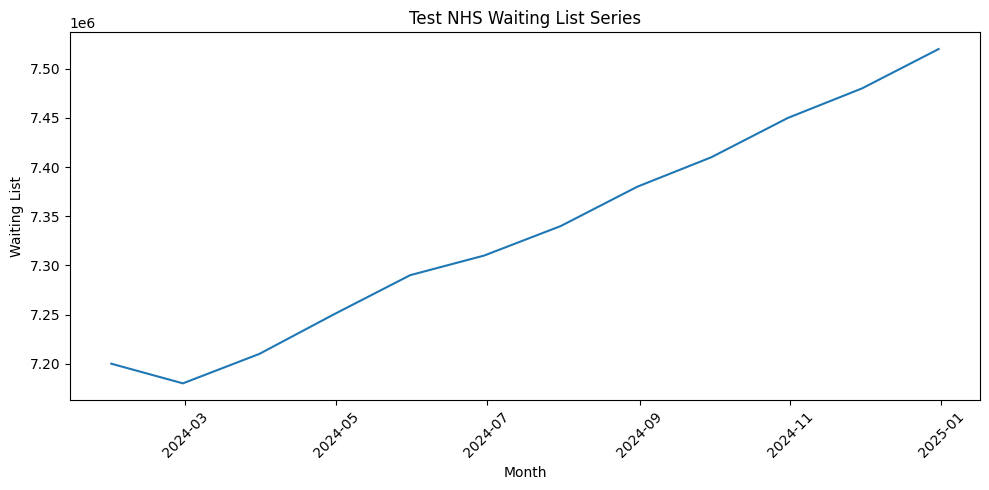

In [7]:
test_df = pd.DataFrame({
    "month": pd.date_range("2024-01-01", periods=12, freq="ME"),
    "waiting_list": [7200000, 7180000, 7210000, 7250000, 7290000, 7310000,
                     7340000, 7380000, 7410000, 7450000, 7480000, 7520000]
})

print(test_df.head())

plt.figure(figsize=(10,5))
plt.plot(test_df["month"], test_df["waiting_list"])
plt.title("Test NHS Waiting List Series")
plt.xlabel("Month")
plt.ylabel("Waiting List")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
plt.tight_layout()
plt.savefig("path_to_file.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

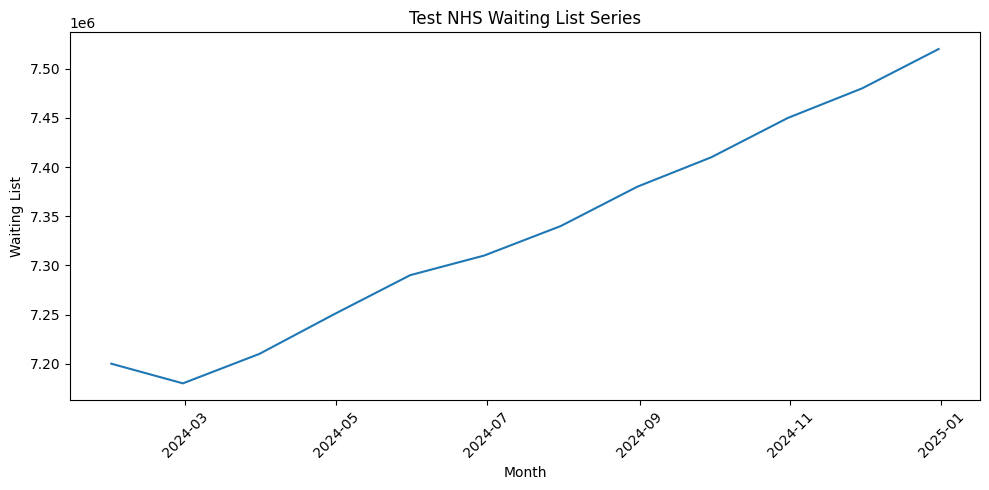

In [11]:
plt.figure(figsize=(10,5))
plt.plot(test_df["month"], test_df["waiting_list"])
plt.title("Test NHS Waiting List Series")
plt.xlabel("Month")
plt.ylabel("Waiting List")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "test_nhs_waiting_list_series.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
rtt_xls_url = "https://www.england.nhs.uk/statistics/wp-content/uploads/sites/2/2026/03/RTT-Overview-Timeseries-Including-Estimates-for-Missing-Trusts-Jan26-XLS-116K-WL5BiP.xlsx"

rtt_book = pd.ExcelFile(rtt_xls_url)

print("Sheet names:")
print(rtt_book.sheet_names)

Sheet names:
['Full Time Series']


In [15]:
rtt_df = pd.read_excel(rtt_xls_url, sheet_name="Full Time Series")

print(rtt_df.shape)
rtt_df.head(10)

(251, 45)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44
0,NaN,Title: Referral to Treatment (RTT) Waiting Tim...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Period: April 2007 to January 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,"Main Source: NHS England, monthly RTT data col...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Unique Patient Source: Waiting List Minimum Da...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Basis: Commissioner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Contact: england.rtt@nhs.net,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Revised:,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Year,Month,Incomplete RTT pathways,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,New RTT periods,NaN,NaN,Completed admitted (adjusted) RTT pathways,NaN,NaN,NaN,NaN


In [17]:
rtt_df.columns.tolist()

['Unnamed: 0',
 'Unnamed: 1',
 'Unnamed: 2',
 'Unnamed: 3',
 'Unnamed: 4',
 'Unnamed: 5',
 'Unnamed: 6',
 'Unnamed: 7',
 'Unnamed: 8',
 'Unnamed: 9',
 'Unnamed: 10',
 'Unnamed: 11',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14',
 'Unnamed: 15',
 'Unnamed: 16',
 'Unnamed: 17',
 'Unnamed: 18',
 'Unnamed: 19',
 'Unnamed: 20',
 'Unnamed: 21',
 'Unnamed: 22',
 'Unnamed: 23',
 'Unnamed: 24',
 'Unnamed: 25',
 'Unnamed: 26',
 'Unnamed: 27',
 'Unnamed: 28',
 'Unnamed: 29',
 'Unnamed: 30',
 'Unnamed: 31',
 'Unnamed: 32',
 'Unnamed: 33',
 'Unnamed: 34',
 'Unnamed: 35',
 'Unnamed: 36',
 'Unnamed: 37',
 'Unnamed: 38',
 'Unnamed: 39',
 'Unnamed: 40',
 'Unnamed: 41',
 'Unnamed: 42',
 'Unnamed: 43',
 'Unnamed: 44']

In [19]:
rtt_df = pd.read_excel(rtt_xls_url, sheet_name="Full Time Series", header=9)

print(rtt_df.shape)
print(rtt_df.columns.tolist())
rtt_df.head()

(242, 45)
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44
0,NaN,Year,Month,Incomplete RTT pathways,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,New RTT periods,NaN,NaN,Completed admitted (adjusted) RTT pathways,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,Median wait (weeks),92nd percentile (weeks),No. within 18 weeks,No. within 18 weeks with estimates for missing...,% within 18 weeks,% within 18 weeks with estimates for missing data,No. > 18 weeks,...,No. of pathways (all),No. of pathways (all) with estimates for missi...,No. of new RTT periods,No. of new RTT periods with estimates for miss...,NaN,Median wait (weeks),95th percentile (weeks),No. within 18 weeks,No. > 52 weeks,No. of pathways (all)
2,NaN,2007/08,2007-04-01 00:00:00,-,-,-,-,-,-,-,...,-,-,-,-,NaN,-,-,-,-,-
3,NaN,NaN,2007-05-01 00:00:00,-,-,-,-,-,-,-,...,-,-,-,-,NaN,-,-,-,-,-
4,NaN,NaN,2007-06-01 00:00:00,-,-,-,-,-,-,-,...,-,-,-,-,NaN,-,-,-,-,-


In [21]:
rtt_df = rtt_df.dropna(axis=1, how="all")

print(rtt_df.shape)
print(rtt_df.columns.tolist())
rtt_df.head()

(242, 43)
['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44']


,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44
0,Year,Month,Incomplete RTT pathways,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,New RTT periods,NaN,Completed admitted (adjusted) RTT pathways,NaN,NaN,NaN,NaN
1,NaN,NaN,Median wait (weeks),92nd percentile (weeks),No. within 18 weeks,No. within 18 weeks with estimates for missing...,% within 18 weeks,% within 18 weeks with estimates for missing data,No. > 18 weeks,No. > 18 weeks with estimates for missing data,...,No. > 52 weeks,No. of pathways (all),No. of pathways (all) with estimates for missi...,No. of new RTT periods,No. of new RTT periods with estimates for miss...,Median wait (weeks),95th percentile (weeks),No. within 18 weeks,No. > 52 weeks,No. of pathways (all)
2,2007/08,2007-04-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
3,NaN,2007-05-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
4,NaN,2007-06-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


In [23]:
rtt_df = pd.read_excel(rtt_xls_url, sheet_name="Full Time Series", header=[9, 10])

rtt_df = rtt_df.dropna(axis=1, how="all")

rtt_df.columns = [
    " ".join(
        str(part).strip()
        for part in col
        if pd.notna(part) and "Unnamed" not in str(part)
    ).strip()
    for col in rtt_df.columns
]

rtt_df = rtt_df.loc[:, rtt_df.columns != ""]

print(rtt_df.shape)
print(rtt_df.columns.tolist())
rtt_df.head()

(241, 43)
['Year', 'Month', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Incomplete RTT pathways', 'Unique Patients', 'Unique Patients', 'Completed admitted (unadjusted) RTT pathways', 'Completed admitted (unadjusted) RTT pathways', 'Completed admitted (unadjusted) RTT pathways', 'Completed admitted (unadjusted) RTT pathways', 'Completed admitted (unadjusted) RTT pathways', 'Completed admitted (unadjusted) RTT pathways', 'Completed non-admitted RTT pathways', 'Completed non-admitted RTT pathways', 'Completed non-admitted RTT 

,Year,Month,Incomplete RTT pathways,Incomplete RTT pathways,Incomplete RTT pathways,Incomplete RTT pathways,Incomplete RTT pathways,Incomplete RTT pathways,Incomplete RTT pathways,Incomplete RTT pathways,...,Completed non-admitted RTT pathways,Completed non-admitted RTT pathways,Completed non-admitted RTT pathways,New RTT periods,New RTT periods,Completed admitted (adjusted) RTT pathways,Completed admitted (adjusted) RTT pathways,Completed admitted (adjusted) RTT pathways,Completed admitted (adjusted) RTT pathways,Completed admitted (adjusted) RTT pathways
0,NaN,NaN,Median wait (weeks),92nd percentile (weeks),No. within 18 weeks,No. within 18 weeks with estimates for missing...,% within 18 weeks,% within 18 weeks with estimates for missing data,No. > 18 weeks,No. > 18 weeks with estimates for missing data,...,No. > 52 weeks,No. of pathways (all),No. of pathways (all) with estimates for missi...,No. of new RTT periods,No. of new RTT periods with estimates for miss...,Median wait (weeks),95th percentile (weeks),No. within 18 weeks,No. > 52 weeks,No. of pathways (all)
1,2007/08,2007-04-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
2,NaN,2007-05-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
3,NaN,2007-06-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
4,NaN,2007-07-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


In [25]:
[col for col in rtt_df.columns if "pathways" in col.lower() or "wait" in col.lower() or "month" in col.lower() or "year" in col.lower()]

['Year',
 'Month',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Incomplete RTT pathways',
 'Completed admitted (unadjusted) RTT pathways',
 'Completed admitted (unadjusted) RTT pathways',
 'Completed admitted (unadjusted) RTT pathways',
 'Completed admitted (unadjusted) RTT pathways',
 'Completed admitted (unadjusted) RTT pathways',
 'Completed admitted (unadjusted) RTT pathways',
 'Completed non-admitted RTT pathways',
 'Completed non-admitted RTT pathways',
 'Completed non-admitted RTT pathways',
 'Compl

In [27]:
top_cols = rtt_df.columns.tolist()
sub_cols = rtt_df.iloc[0].tolist()

new_cols = []
seen = {}

for top, sub in zip(top_cols, sub_cols):
    top = "" if pd.isna(top) else str(top).strip()
    sub = "" if pd.isna(sub) else str(sub).strip()

    name_parts = [x for x in [top, sub] if x and x.lower() != "nan"]
    name = " ".join(name_parts).strip()

    if name == "":
        name = "blank_column"

    if name in seen:
        seen[name] += 1
        name = f"{name}_{seen[name]}"
    else:
        seen[name] = 0

    new_cols.append(name)

rtt_df.columns = new_cols
rtt_df = rtt_df.iloc[1:].reset_index(drop=True)

print(rtt_df.shape)
print(rtt_df.columns.tolist())
rtt_df.head()

(240, 43)
['Year', 'Month', 'Incomplete RTT pathways Median wait (weeks)', 'Incomplete RTT pathways 92nd percentile (weeks)', 'Incomplete RTT pathways No. within 18 weeks', 'Incomplete RTT pathways No. within 18 weeks with estimates for missing data', 'Incomplete RTT pathways % within 18 weeks', 'Incomplete RTT pathways % within 18 weeks with estimates for missing data', 'Incomplete RTT pathways No. > 18 weeks', 'Incomplete RTT pathways No. > 18 weeks with estimates for missing data', 'Incomplete RTT pathways No. > 52 weeks', 'Incomplete RTT pathways No. > 52 weeks with estimates for missing data', 'Incomplete RTT pathways % > 52 weeks', 'Incomplete RTT pathways % > 52 weeks with estimates for missing data', 'Incomplete RTT pathways No. > 65 weeks', 'Incomplete RTT pathways No. > 65 weeks with estimates for missing data', 'Incomplete RTT pathways No. > 78 weeks', 'Incomplete RTT pathways No. > 78 weeks with estimates for missing data', 'Incomplete RTT pathways No. > 104 weeks', 'Incomp

,Year,Month,Incomplete RTT pathways Median wait (weeks),Incomplete RTT pathways 92nd percentile (weeks),Incomplete RTT pathways No. within 18 weeks,Incomplete RTT pathways No. within 18 weeks with estimates for missing data,Incomplete RTT pathways % within 18 weeks,Incomplete RTT pathways % within 18 weeks with estimates for missing data,Incomplete RTT pathways No. > 18 weeks,Incomplete RTT pathways No. > 18 weeks with estimates for missing data,...,Completed non-admitted RTT pathways No. > 52 weeks,Completed non-admitted RTT pathways No. of pathways (all),Completed non-admitted RTT pathways No. of pathways (all) with estimates for missing data,New RTT periods No. of new RTT periods,New RTT periods No. of new RTT periods with estimates for missing data,Completed admitted (adjusted) RTT pathways Median wait (weeks),Completed admitted (adjusted) RTT pathways 95th percentile (weeks),Completed admitted (adjusted) RTT pathways No. within 18 weeks,Completed admitted (adjusted) RTT pathways No. > 52 weeks,Completed admitted (adjusted) RTT pathways No. of pathways (all)
0,2007/08,2007-04-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
1,NaN,2007-05-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
2,NaN,2007-06-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
3,NaN,2007-07-01 00:00:00,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
4,NaN,2007-08-01 00:00:00,14.287783,52+,2395656,2395656,0.572169,0.572169,1791318,1791318,...,68141,835346,848812.582609,-,-,-,-,-,-,-


In [29]:
[c for c in rtt_df.columns if "incomplete rtt pathways" in c.lower() or c.lower() in ["year", "month"]]

['Year',
 'Month',
 'Incomplete RTT pathways Median wait (weeks)',
 'Incomplete RTT pathways 92nd percentile (weeks)',
 'Incomplete RTT pathways No. within 18 weeks',
 'Incomplete RTT pathways No. within 18 weeks with estimates for missing data',
 'Incomplete RTT pathways % within 18 weeks',
 'Incomplete RTT pathways % within 18 weeks with estimates for missing data',
 'Incomplete RTT pathways No. > 18 weeks',
 'Incomplete RTT pathways No. > 18 weeks with estimates for missing data',
 'Incomplete RTT pathways No. > 52 weeks',
 'Incomplete RTT pathways No. > 52 weeks with estimates for missing data',
 'Incomplete RTT pathways % > 52 weeks',
 'Incomplete RTT pathways % > 52 weeks with estimates for missing data',
 'Incomplete RTT pathways No. > 65 weeks',
 'Incomplete RTT pathways No. > 65 weeks with estimates for missing data',
 'Incomplete RTT pathways No. > 78 weeks',
 'Incomplete RTT pathways No. > 78 weeks with estimates for missing data',
 'Incomplete RTT pathways No. > 104 weeks',

In [31]:
waiting_ts = rtt_df[[
    "Month",
    "Incomplete RTT pathways Total waiting (mil)"
]].copy()

waiting_ts = waiting_ts.rename(columns={
    "Month": "month",
    "Incomplete RTT pathways Total waiting (mil)": "waiting_mil"
})

waiting_ts["month"] = pd.to_datetime(waiting_ts["month"], errors="coerce")
waiting_ts["waiting_mil"] = pd.to_numeric(waiting_ts["waiting_mil"], errors="coerce")

waiting_ts = waiting_ts.dropna(subset=["month", "waiting_mil"]).sort_values("month").reset_index(drop=True)
waiting_ts["waiting_list"] = waiting_ts["waiting_mil"] * 1_000_000

print(waiting_ts.shape)
waiting_ts.head()

(221, 3)


,month,waiting_mil,waiting_list
0,2007-08-01,4186974.0,4.186974e+12
1,2007-09-01,3997551.0,3.997551e+12
2,2007-10-01,3939821.0,3.939821e+12
3,2007-11-01,3921962.0,3.921962e+12
4,2007-12-01,3853836.0,3.853836e+12


In [33]:
waiting_ts.tail()

,month,waiting_mil,waiting_list
216,2025-09-01,7296893.0,7.296893e+12
217,2025-10-01,7304189.0,7.304189e+12
218,2025-11-01,7159010.0,7.159010e+12
219,2025-12-01,7199624.0,7.199624e+12
220,2026-01-01,7155958.0,7.155958e+12


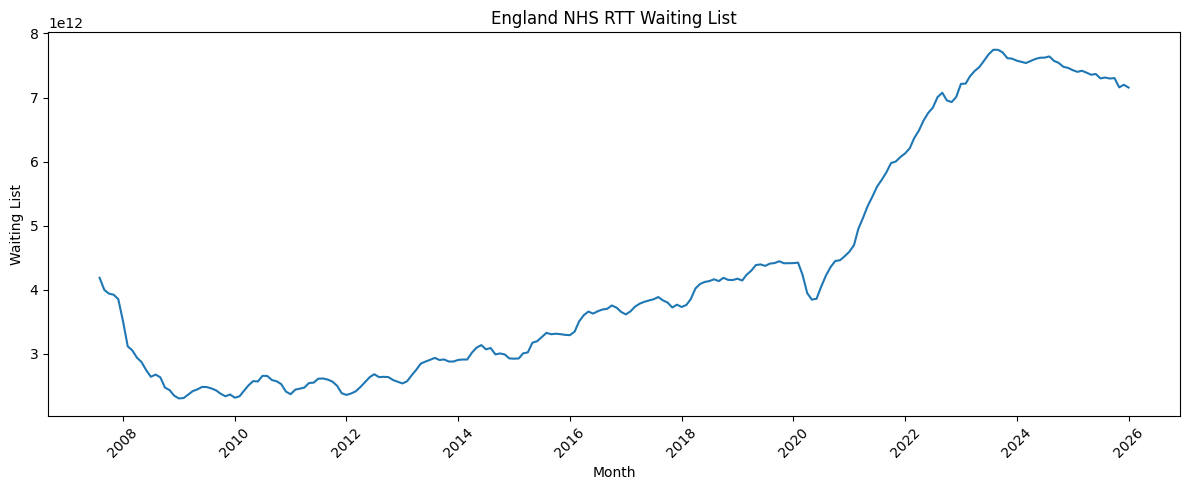

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(waiting_ts["month"], waiting_ts["waiting_list"])
plt.title("England NHS RTT Waiting List")
plt.xlabel("Month")
plt.ylabel("Waiting List")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "england_nhs_rtt_waiting_list.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
waiting_ts = rtt_df[[
    "Month",
    "Incomplete RTT pathways Total waiting (mil)"
]].copy()

waiting_ts = waiting_ts.rename(columns={
    "Month": "month",
    "Incomplete RTT pathways Total waiting (mil)": "waiting_list"
})

waiting_ts["month"] = pd.to_datetime(waiting_ts["month"], errors="coerce")
waiting_ts["waiting_list"] = pd.to_numeric(waiting_ts["waiting_list"], errors="coerce")

waiting_ts = (
    waiting_ts
    .dropna(subset=["month", "waiting_list"])
    .sort_values("month")
    .reset_index(drop=True)
)

print(waiting_ts.shape)
waiting_ts.head()

(221, 2)


,month,waiting_list
0,2007-08-01,4186974.0
1,2007-09-01,3997551.0
2,2007-10-01,3939821.0
3,2007-11-01,3921962.0
4,2007-12-01,3853836.0


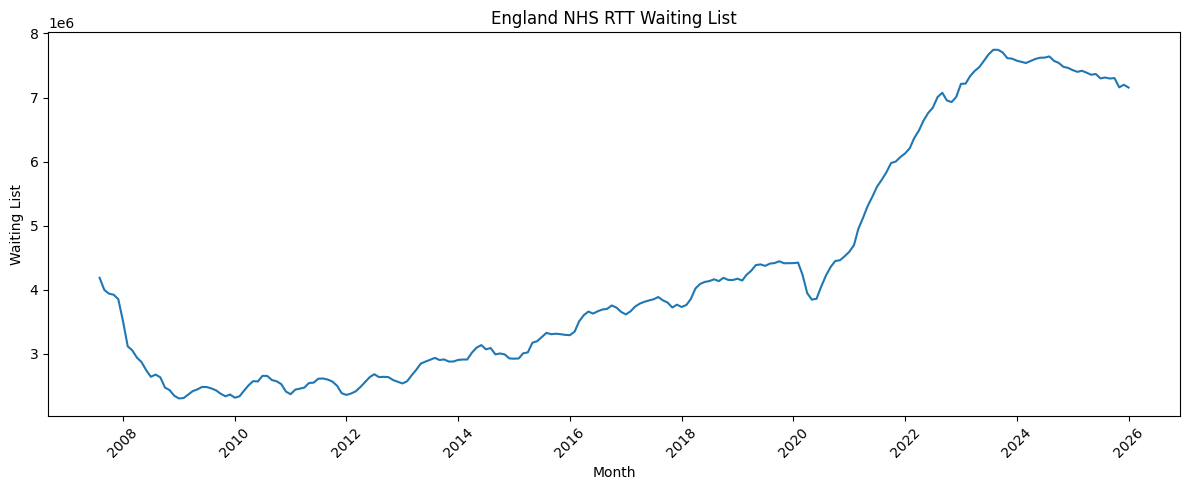

In [39]:
plt.figure(figsize=(12, 5))
plt.plot(waiting_ts["month"], waiting_ts["waiting_list"])
plt.title("England NHS RTT Waiting List")
plt.xlabel("Month")
plt.ylabel("Waiting List")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "england_nhs_rtt_waiting_list_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
waiting_recent = waiting_ts[waiting_ts["month"] >= "2018-01-01"].copy().reset_index(drop=True)

print(waiting_recent.shape)
waiting_recent.head()

(96, 2)


,month,waiting_list
0,2018-01-01,3730473.0
1,2018-02-01,3763533.0
2,2018-03-01,3852414.0
3,2018-04-01,4019507.0
4,2018-05-01,4089937.0


In [43]:
waiting_recent.tail()

,month,waiting_list
91,2025-09-01,7296893.0
92,2025-10-01,7304189.0
93,2025-11-01,7159010.0
94,2025-12-01,7199624.0
95,2026-01-01,7155958.0


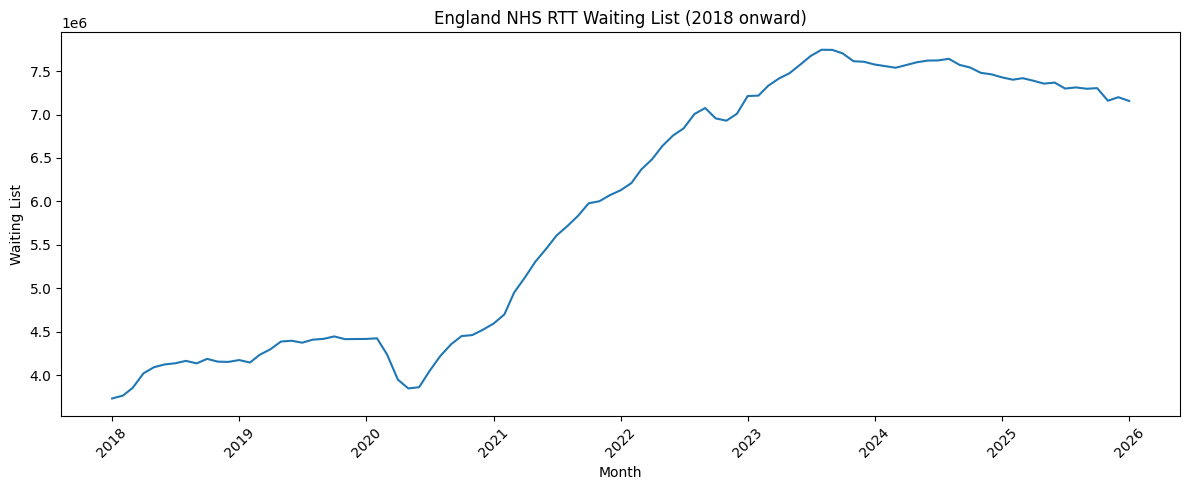

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(waiting_recent["month"], waiting_recent["waiting_list"])
plt.title("England NHS RTT Waiting List (2018 onward)")
plt.xlabel("Month")
plt.ylabel("Waiting List")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "england_nhs_rtt_waiting_list_2018_onward.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
decomp_input = waiting_recent.set_index("month")["waiting_list"].asfreq("MS")

decomp = seasonal_decompose(decomp_input, model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "england_nhs_rtt_decomposition_2018_onward.png", dpi=300, bbox_inches="tight")
plt.show()

ValueError: This function does not handle missing values

In [49]:
decomp_input = waiting_recent.set_index("month")["waiting_list"].asfreq("MS")

print("Missing values:", decomp_input.isna().sum())
print(decomp_input[decomp_input.isna()])

Missing values: 1
month
2024-02-01   NaN
Freq: MS, Name: waiting_list, dtype: float64


In [51]:
decomp_input = waiting_recent.set_index("month")["waiting_list"].asfreq("MS")
decomp_input = decomp_input.interpolate(method="linear")

print("Missing values after fix:", decomp_input.isna().sum())

Missing values after fix: 0


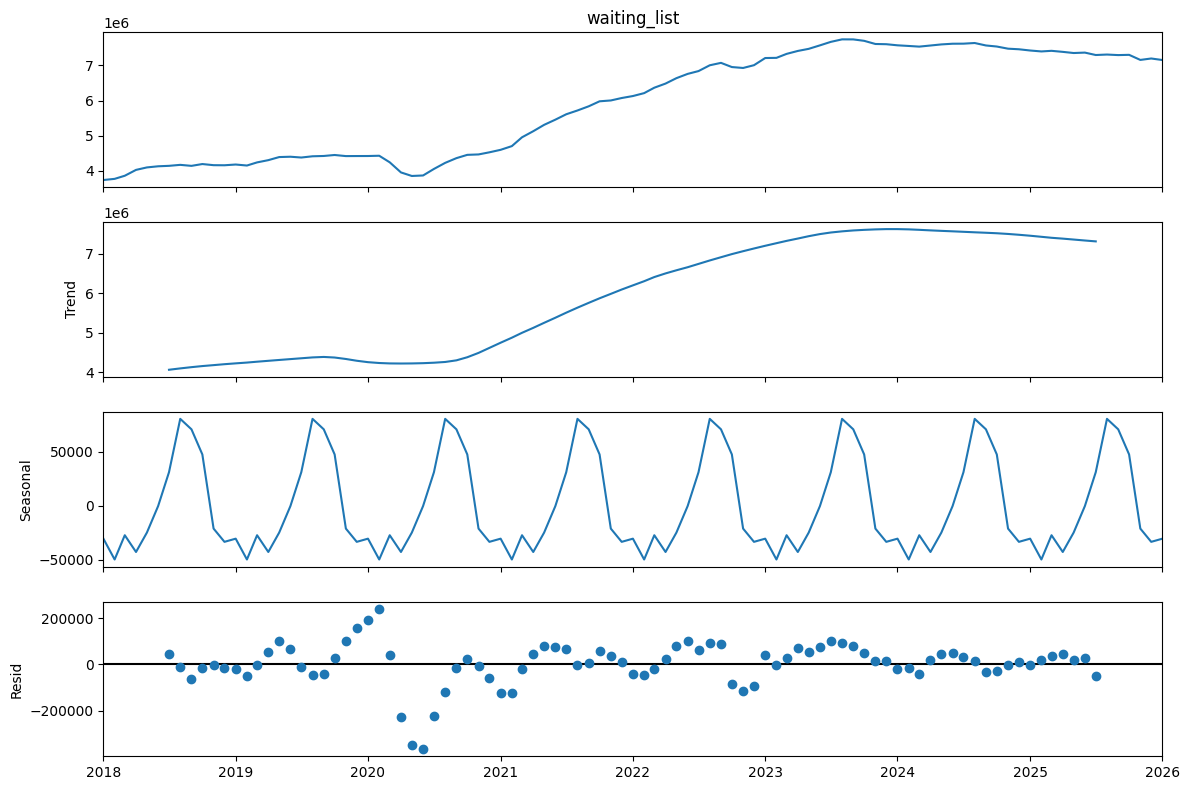

In [53]:
decomp = seasonal_decompose(decomp_input, model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "england_nhs_rtt_decomposition_2018_onward.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
forecast_input = waiting_recent.set_index("month")["waiting_list"].asfreq("MS")
forecast_input = forecast_input.interpolate(method="linear")

In [57]:
hw_model = ExponentialSmoothing(
    forecast_input,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

forecast_steps = 12
forecast_values = hw_model.forecast(forecast_steps)

forecast_df = pd.DataFrame({
    "month": pd.date_range(
        start=forecast_input.index[-1] + pd.offsets.MonthBegin(1),
        periods=forecast_steps,
        freq="MS"
    ),
    "forecast_waiting_list": forecast_values.values
})

forecast_df

,month,forecast_waiting_list
0,2026-02-01,7.137461e+06
1,2026-03-01,7.134075e+06
2,2026-04-01,7.117974e+06
3,2026-05-01,7.106909e+06
4,2026-06-01,7.125662e+06
5,2026-07-01,7.133818e+06
6,2026-08-01,7.177161e+06
7,2026-09-01,7.180499e+06
8,2026-10-01,7.175813e+06
9,2026-11-01,7.107988e+06


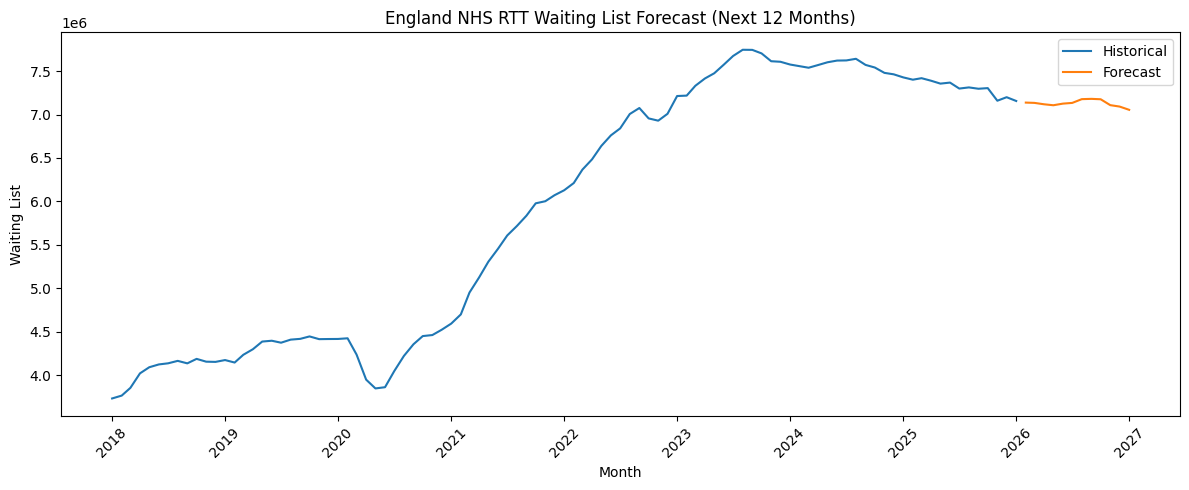

In [59]:
plt.figure(figsize=(12, 5))
plt.plot(waiting_recent["month"], waiting_recent["waiting_list"], label="Historical")
plt.plot(forecast_df["month"], forecast_df["forecast_waiting_list"], label="Forecast")
plt.title("England NHS RTT Waiting List Forecast (Next 12 Months)")
plt.xlabel("Month")
plt.ylabel("Waiting List")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "england_nhs_rtt_forecast_12_months.png", dpi=300, bbox_inches="tight")
plt.show()

In [61]:
model_series = waiting_recent.set_index("month")["waiting_list"].asfreq("MS")
model_series = model_series.interpolate(method="linear")

train = model_series.iloc[:-12]
test = model_series.iloc[-12:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train end:", train.index[-1])
print("Test start:", test.index[0])
print("Test end:", test.index[-1])

Train shape: (85,)
Test shape: (12,)
Train end: 2025-01-01 00:00:00
Test start: 2025-02-01 00:00:00
Test end: 2026-01-01 00:00:00


In [63]:
hw_test_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

test_forecast = hw_test_model.forecast(len(test))

test_results = pd.DataFrame({
    "month": test.index,
    "actual": test.values,
    "forecast": test_forecast.values
})

test_results.head()

,month,actual,forecast
0,2025-02-01,7401153.0,7.408020e+06
1,2025-03-01,7418598.0,7.401119e+06
2,2025-04-01,7389065.0,7.384169e+06
3,2025-05-01,7355950.0,7.372957e+06
4,2025-06-01,7367836.0,7.382715e+06


In [65]:
test_results["error"] = test_results["actual"] - test_results["forecast"]
test_results["abs_error"] = test_results["error"].abs()
test_results["sq_error"] = test_results["error"] ** 2
test_results["ape"] = (test_results["abs_error"] / test_results["actual"]) * 100

mae = test_results["abs_error"].mean()
rmse = np.sqrt(test_results["sq_error"].mean())
mape = test_results["ape"].mean()

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 89,075.30
RMSE: 113,131.50
MAPE: 1.23%


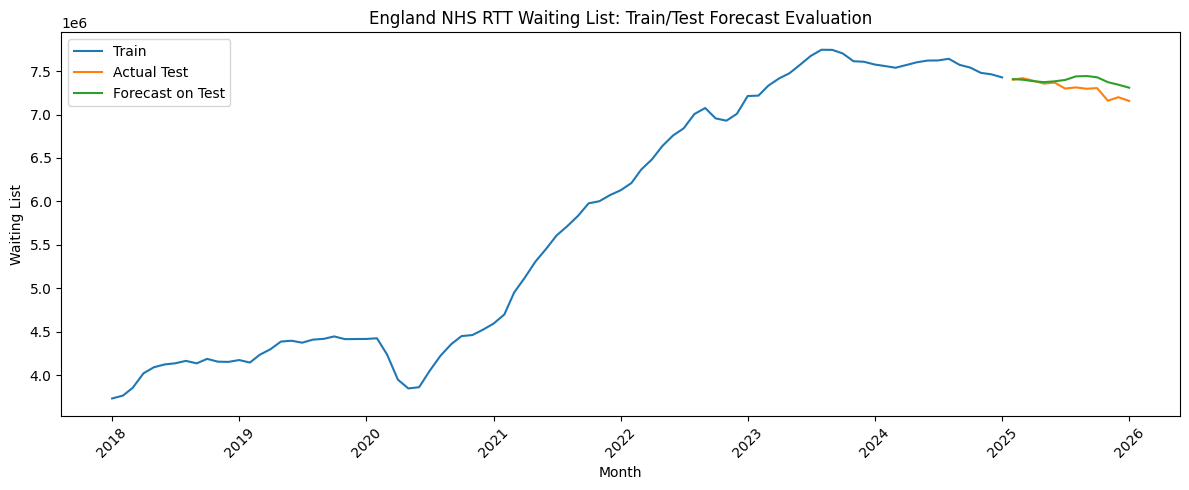

In [67]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Actual Test")
plt.plot(test_results["month"], test_results["forecast"], label="Forecast on Test")
plt.title("England NHS RTT Waiting List: Train/Test Forecast Evaluation")
plt.xlabel("Month")
plt.ylabel("Waiting List")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "england_nhs_rtt_train_test_evaluation.png", dpi=300, bbox_inches="tight")
plt.show()

In [69]:
test_results.to_csv(BASE_DIR / "outputs" / "tables" / "england_nhs_rtt_test_results.csv", index=False)
test_results

,month,actual,forecast,error,abs_error,sq_error,ape
0,2025-02-01,7401153.0,7.408020e+06,-6866.807657,6866.807657,4.715305e+07,0.092780
1,2025-03-01,7418598.0,7.401119e+06,17478.765144,17478.765144,3.055072e+08,0.235607
2,2025-04-01,7389065.0,7.384169e+06,4896.276771,4896.276771,2.397353e+07,0.066264
3,2025-05-01,7355950.0,7.372957e+06,-17007.190448,17007.190448,2.892445e+08,0.231203
4,2025-06-01,7367836.0,7.382715e+06,-14879.261654,14879.261654,2.213924e+08,0.201949
5,2025-07-01,7299023.0,7.398068e+06,-99044.556297,99044.556297,9.809824e+09,1.356956
6,2025-08-01,7312356.0,7.439295e+06,-126939.000140,126939.000140,1.611351e+10,1.735952
7,2025-09-01,7296893.0,7.443301e+06,-146407.798606,146407.798606,2.143524e+10,2.006440
8,2025-10-01,7304189.0,7.429044e+06,-124854.724705,124854.724705,1.558870e+10,1.709358
9,2025-11-01,7159010.0,7.372579e+06,-213568.714368,213568.714368,4.561160e+10,2.983216


In [71]:
worst_months = test_results.sort_values("abs_error", ascending=False).reset_index(drop=True)
worst_months.head(12)

,month,actual,forecast,error,abs_error,sq_error,ape
0,2025-11-01,7159010.0,7.372579e+06,-213568.714368,213568.714368,4.561160e+10,2.983216
1,2026-01-01,7155958.0,7.309229e+06,-153271.031680,153271.031680,2.349201e+10,2.141866
2,2025-09-01,7296893.0,7.443301e+06,-146407.798606,146407.798606,2.143524e+10,2.006440
3,2025-12-01,7199624.0,7.343314e+06,-143689.509914,143689.509914,2.064668e+10,1.995792
4,2025-08-01,7312356.0,7.439295e+06,-126939.000140,126939.000140,1.611351e+10,1.735952
5,2025-10-01,7304189.0,7.429044e+06,-124854.724705,124854.724705,1.558870e+10,1.709358
6,2025-07-01,7299023.0,7.398068e+06,-99044.556297,99044.556297,9.809824e+09,1.356956
7,2025-03-01,7418598.0,7.401119e+06,17478.765144,17478.765144,3.055072e+08,0.235607
8,2025-05-01,7355950.0,7.372957e+06,-17007.190448,17007.190448,2.892445e+08,0.231203
9,2025-06-01,7367836.0,7.382715e+06,-14879.261654,14879.261654,2.213924e+08,0.201949


In [73]:
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

naive_results = pd.DataFrame({
    "month": test.index,
    "actual": test.values,
    "forecast": naive_forecast.values
})

naive_results["error"] = naive_results["actual"] - naive_results["forecast"]
naive_results["abs_error"] = naive_results["error"].abs()
naive_results["sq_error"] = naive_results["error"] ** 2
naive_results["ape"] = (naive_results["abs_error"] / naive_results["actual"]) * 100

naive_mae = naive_results["abs_error"].mean()
naive_rmse = np.sqrt(naive_results["sq_error"].mean())
naive_mape = naive_results["ape"].mean()

comparison_df = pd.DataFrame({
    "model": ["Holt-Winters", "Naive"],
    "MAE": [mae, naive_mae],
    "RMSE": [rmse, naive_rmse],
    "MAPE": [mape, naive_mape]
})

comparison_df

,model,MAE,RMSE,MAPE
0,Holt-Winters,89075.303115,113131.498189,1.229782
1,Naive,122697.750000,150334.309305,1.694122


In [75]:
rtt_book.sheet_names

['Full Time Series']

In [77]:
[s for s in rtt_book.sheet_names if "special" in s.lower() or "treat" in s.lower() or "function" in s.lower() or "provider" in s.lower()]

[]

In [79]:
specialty_df = pd.DataFrame([
    ["General Surgery Service", 386068, 59.6, 25012, 50112, 90835],
    ["Urology Service", 389052, 62.8, 19618, 57706, 94892],
    ["Trauma and Orthopaedic Service", 836764, 57.9, 46693, 102356, 162835],
    ["Ear Nose and Throat Service", 587673, 53.4, 13018, 88225, 111875],
    ["Ophthalmology Service", 596635, 69.7, 53711, 107614, 176052],
    ["Oral Surgery Service", 317724, 52.4, 13545, 38966, 55878],
    ["Neurosurgical Service", 57289, 60.3, 2369, 7969, 11764],
    ["Plastic Surgery Service", 103068, 54.3, 12266, 10507, 22568],
    ["Cardiothoracic Surgery Service", 9041, 71.4, 1349, 1205, 2500],
    ["General Internal Medicine Service", 34818, 66.6, 880, 7355, 10685],
    ["Gastroenterology Service", 383007, 64.8, 17375, 54587, 99323],
    ["Cardiology Service", 383680, 63.9, 9715, 61724, 89900],
    ["Dermatology Service", 396171, 59.8, 11921, 97496, 113870],
    ["Respiratory Medicine Service", 184826, 69.4, 2227, 40695, 54050],
    ["Neurology Service", 216423, 57.0, 581, 32642, 41039],
    ["Rheumatology Service", 115918, 66.3, 1415, 26878, 30474],
    ["Elderly Medicine Service", 26332, 79.3, 500, 8812, 10539],
    ["Gynaecology Service", 565134, 56.9, 16011, 91215, 119573],
    ["Other - Medical Services", 616287, 66.1, 15747, 139407, 176624],
    ["Other - Mental Health Services", 2969, 77.0, 7, 941, 882],
    ["Other - Paediatric Services", 314575, 63.3, 10188, 61382, 78100],
    ["Other - Surgical Services", 481591, 62.2, 22960, 107685, 154704],
    ["Other - Other Services", 150913, 73.9, 4563, 51464, 58622],
], columns=[
    "treatment_function",
    "incomplete_pathways",
    "pct_within_18_weeks",
    "completed_admitted",
    "completed_non_admitted",
    "new_rtt_periods"
])

specialty_df

,treatment_function,incomplete_pathways,pct_within_18_weeks,completed_admitted,completed_non_admitted,new_rtt_periods
0,General Surgery Service,386068,59.6,25012,50112,90835
1,Urology Service,389052,62.8,19618,57706,94892
2,Trauma and Orthopaedic Service,836764,57.9,46693,102356,162835
3,Ear Nose and Throat Service,587673,53.4,13018,88225,111875
4,Ophthalmology Service,596635,69.7,53711,107614,176052
5,Oral Surgery Service,317724,52.4,13545,38966,55878
6,Neurosurgical Service,57289,60.3,2369,7969,11764
7,Plastic Surgery Service,103068,54.3,12266,10507,22568
8,Cardiothoracic Surgery Service,9041,71.4,1349,1205,2500
9,General Internal Medicine Service,34818,66.6,880,7355,10685


In [81]:
top_backlog = specialty_df.sort_values("incomplete_pathways", ascending=False).reset_index(drop=True)
top_backlog.head(10)

,treatment_function,incomplete_pathways,pct_within_18_weeks,completed_admitted,completed_non_admitted,new_rtt_periods
0,Trauma and Orthopaedic Service,836764,57.9,46693,102356,162835
1,Other - Medical Services,616287,66.1,15747,139407,176624
2,Ophthalmology Service,596635,69.7,53711,107614,176052
3,Ear Nose and Throat Service,587673,53.4,13018,88225,111875
4,Gynaecology Service,565134,56.9,16011,91215,119573
5,Other - Surgical Services,481591,62.2,22960,107685,154704
6,Dermatology Service,396171,59.8,11921,97496,113870
7,Urology Service,389052,62.8,19618,57706,94892
8,General Surgery Service,386068,59.6,25012,50112,90835
9,Cardiology Service,383680,63.9,9715,61724,89900


In [83]:
worst_18_week = specialty_df.sort_values("pct_within_18_weeks", ascending=True).reset_index(drop=True)
worst_18_week.head(10)

,treatment_function,incomplete_pathways,pct_within_18_weeks,completed_admitted,completed_non_admitted,new_rtt_periods
0,Oral Surgery Service,317724,52.4,13545,38966,55878
1,Ear Nose and Throat Service,587673,53.4,13018,88225,111875
2,Plastic Surgery Service,103068,54.3,12266,10507,22568
3,Gynaecology Service,565134,56.9,16011,91215,119573
4,Neurology Service,216423,57.0,581,32642,41039
5,Trauma and Orthopaedic Service,836764,57.9,46693,102356,162835
6,General Surgery Service,386068,59.6,25012,50112,90835
7,Dermatology Service,396171,59.8,11921,97496,113870
8,Neurosurgical Service,57289,60.3,2369,7969,11764
9,Other - Surgical Services,481591,62.2,22960,107685,154704


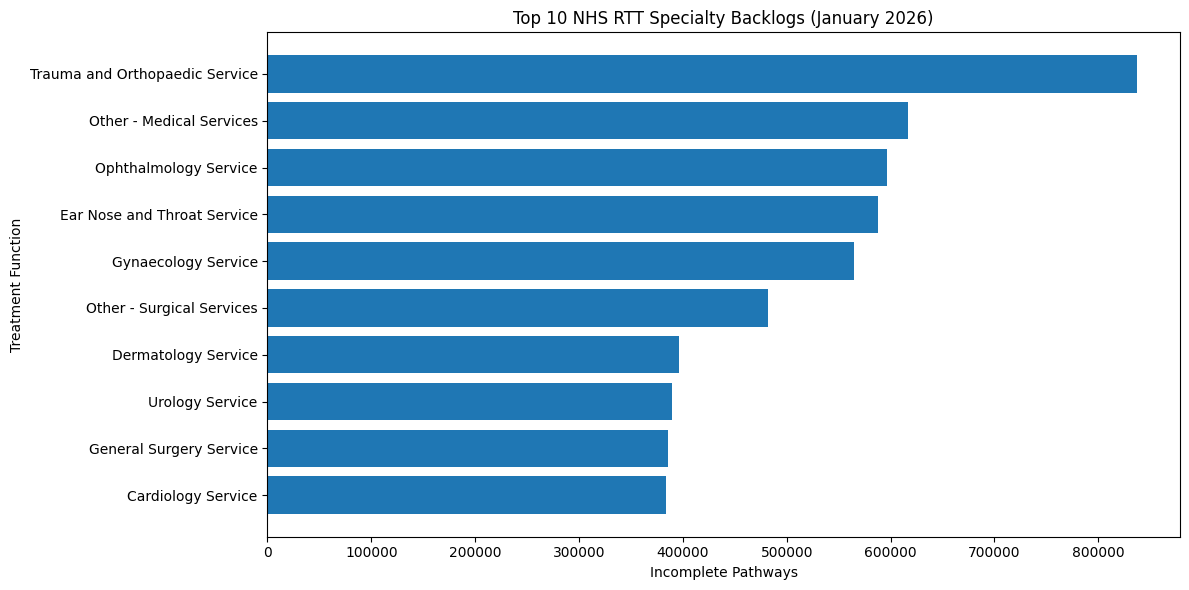

In [85]:
top10_backlog = top_backlog.head(10).sort_values("incomplete_pathways", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(top10_backlog["treatment_function"], top10_backlog["incomplete_pathways"])
plt.title("Top 10 NHS RTT Specialty Backlogs (January 2026)")
plt.xlabel("Incomplete Pathways")
plt.ylabel("Treatment Function")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "specialty_top10_backlog_jan2026.png", dpi=300, bbox_inches="tight")
plt.show()

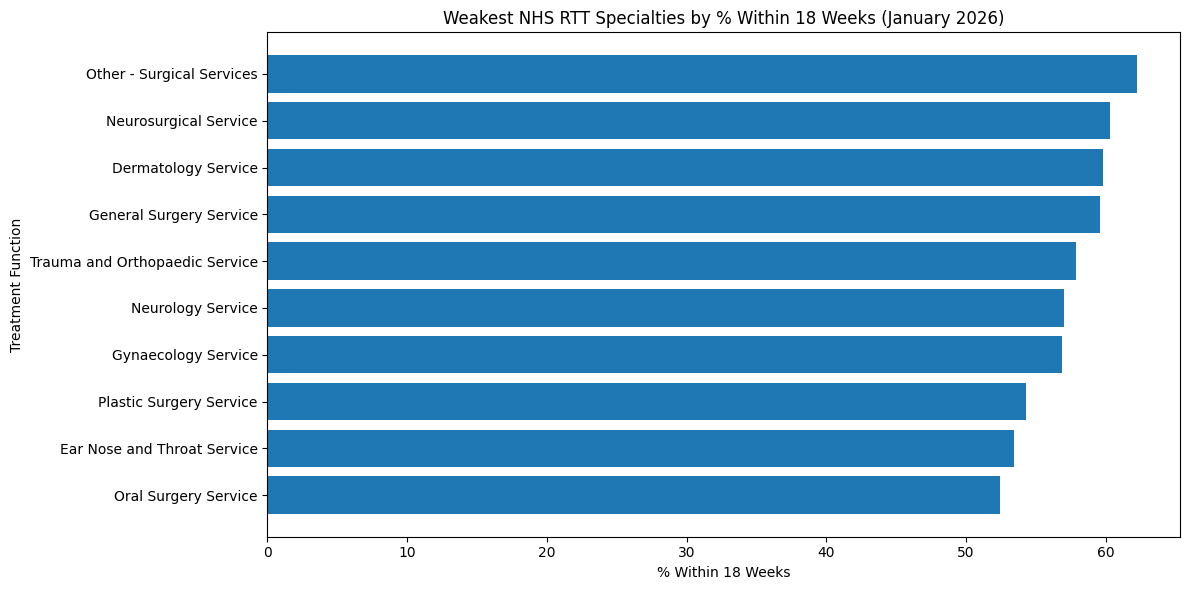

In [87]:
worst10_18 = worst_18_week.head(10).sort_values("pct_within_18_weeks", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(worst10_18["treatment_function"], worst10_18["pct_within_18_weeks"])
plt.title("Weakest NHS RTT Specialties by % Within 18 Weeks (January 2026)")
plt.xlabel("% Within 18 Weeks")
plt.ylabel("Treatment Function")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "specialty_worst18weeks_jan2026.png", dpi=300, bbox_inches="tight")
plt.show()

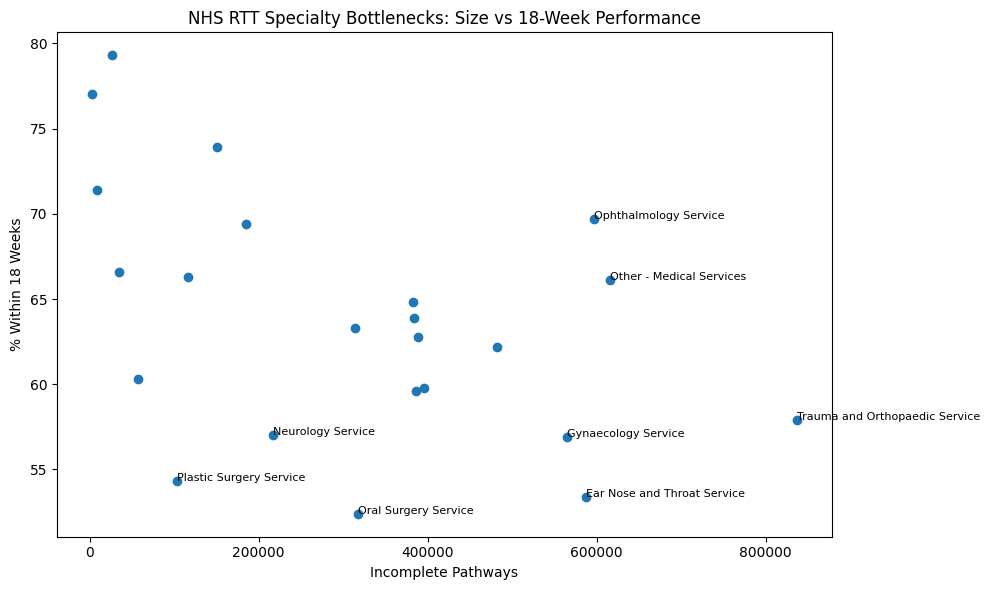

In [89]:
plt.figure(figsize=(10, 6))
plt.scatter(specialty_df["incomplete_pathways"], specialty_df["pct_within_18_weeks"])

for _, row in specialty_df.iterrows():
    if row["incomplete_pathways"] >= 500000 or row["pct_within_18_weeks"] <= 58:
        plt.annotate(
            row["treatment_function"],
            (row["incomplete_pathways"], row["pct_within_18_weeks"]),
            fontsize=8
        )

plt.title("NHS RTT Specialty Bottlenecks: Size vs 18-Week Performance")
plt.xlabel("Incomplete Pathways")
plt.ylabel("% Within 18 Weeks")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "specialty_bottleneck_scatter_jan2026.png", dpi=300, bbox_inches="tight")
plt.show()

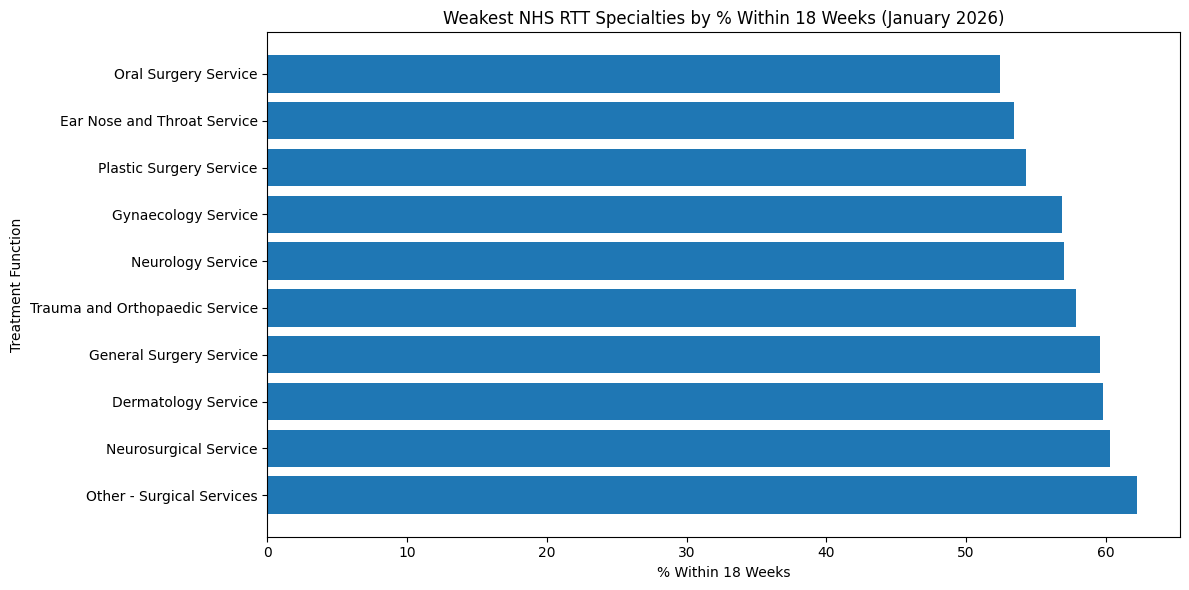

In [91]:
worst10_18 = worst_18_week.head(10).sort_values("pct_within_18_weeks", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(worst10_18["treatment_function"], worst10_18["pct_within_18_weeks"])
plt.title("Weakest NHS RTT Specialties by % Within 18 Weeks (January 2026)")
plt.xlabel("% Within 18 Weeks")
plt.ylabel("Treatment Function")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "specialty_worst18weeks_jan2026_fixed.png", dpi=300, bbox_inches="tight")
plt.show()

In [95]:
commissioner_url = "https://www.england.nhs.uk/statistics/wp-content/uploads/sites/2/2026/03/Incomplete-Commissioner-Jan26-XLSX-4M-WL5BiP.xlsx"
provider_url = "https://www.england.nhs.uk/statistics/wp-content/uploads/sites/2/2026/03/Incomplete-Provider-Jan26-XLSX-9M-WL5BiP.xlsx"

comm_book = pd.ExcelFile(commissioner_url)

print(comm_book.sheet_names)

['National', 'National with DTA', 'Region', 'Region with DTA', 'ICB', 'ICB with DTA', 'Sub-ICB', 'Sub-ICB with DTA', 'Notes', 'Guidance']


In [97]:
comm_region_raw = pd.read_excel(commissioner_url, sheet_name="Region", header=None)

print(comm_region_raw.shape)
comm_region_raw.head(12)

(206, 119)


,0,1,2,3,4,5,6,7,8,9,...,109,110,111,112,113,114,115,116,117,118
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Title:,Referral to Treatment (RTT) Waiting Times,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,[The '+' button above reveals the full weekly ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Summary:,Monthly Referral to Treatment (RTT) waiting ti...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Period:,January 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Source:,NHS England: monthly RTT data collection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Basis:,Commissioner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Published:,12th March 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,Revised:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Status:,Published,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
comm_region_raw.iloc[:15, :12]

,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Title:,Referral to Treatment (RTT) Waiting Times,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Summary:,Monthly Referral to Treatment (RTT) waiting ti...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Period:,January 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Source:,NHS England: monthly RTT data collection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Basis:,Commissioner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Published:,12th March 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,Revised:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Status:,Published,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
comm_region = pd.read_excel(commissioner_url, sheet_name="Region", header=13)

comm_region = comm_region.dropna(axis=1, how="all")
comm_region = comm_region.loc[:, ~comm_region.columns.astype(str).str.contains("^Unnamed")]

print(comm_region.shape)
print(comm_region.columns.tolist())
comm_region.head()

(192, 118)
['Region Code', 'Region Name', 'Treatment Function Code', 'Treatment Function', '>0-1', '>1-2', '>2-3', '>3-4', '>4-5', '>5-6', '>6-7', '>7-8', '>8-9', '>9-10', '>10-11', '>11-12', '>12-13', '>13-14', '>14-15', '>15-16', '>16-17', '>17-18', '>18-19', '>19-20', '>20-21', '>21-22', '>22-23', '>23-24', '>24-25', '>25-26', '>26-27', '>27-28', '>28-29', '>29-30', '>30-31', '>31-32', '>32-33', '>33-34', '>34-35', '>35-36', '>36-37', '>37-38', '>38-39', '>39-40', '>40-41', '>41-42', '>42-43', '>43-44', '>44-45', '>45-46', '>46-47', '>47-48', '>48-49', '>49-50', '>50-51', '>51-52', '>52-53', '>53-54', '>54-55', '>55-56', '>56-57', '>57-58', '>58-59', '>59-60', '>60-61', '>61-62', '>62-63', '>63-64', '>64-65', '>65-66', '>66-67', '>67-68', '>68-69', '>69-70', '>70-71', '>71-72', '>72-73', '>73-74', '>74-75', '>75-76', '>76-77', '>77-78', '>78-79', '>79-80', '>80-81', '>81-82', '>82-83', '>83-84', '>84-85', '>85-86', '>86-87', '>87-88', '>88-89', '>89-90', '>90-91', '>91-92', '>92-93'

,Region Code,Region Name,Treatment Function Code,Treatment Function,>0-1,>1-2,>2-3,>3-4,>4-5,>5-6,...,104 plus,Total number of incomplete pathways,Total within 18 weeks,% within 18 weeks,Average (median) waiting time (in weeks),92nd percentile waiting time (in weeks),Total 52 plus weeks,Total 78 plus weeks,Total 65 plus weeks,% 52 plus weeks
0,-,NHS ENGLAND,C_100,General Surgery Service,140,138,130,135,66,48,...,0,2927,1680,0.573967,15.230337,39.745,38,0,1,0.012983
1,-,NHS ENGLAND,C_101,Urology Service,77,75,71,56,52,29,...,28,1966,1057,0.537640,16.195122,50.714667,146,68,88,0.074262
2,-,NHS ENGLAND,C_110,Trauma and Orthopaedic Service,195,216,202,219,107,114,...,0,5199,3070,0.590498,14.567857,42.317895,146,1,9,0.028082
3,-,NHS ENGLAND,C_120,Ear Nose and Throat Service,129,127,136,118,83,47,...,0,3443,1880,0.546035,16.275281,42.8925,66,0,2,0.019169
4,-,NHS ENGLAND,C_130,Ophthalmology Service,143,182,139,127,113,52,...,0,2848,1848,0.648876,12.206897,39.797895,33,0,0,0.011587


In [103]:
[c for c in comm_region.columns if "Region" in str(c) or "Treatment" in str(c) or "18" in str(c) or "52" in str(c) or "Total" in str(c) or "%" in str(c)]

['Region Code',
 'Region Name',
 'Treatment Function Code',
 'Treatment Function',
 '>17-18',
 '>18-19',
 '>51-52',
 '>52-53',
 'Total number of incomplete pathways',
 'Total within 18 weeks',
 '% within 18 weeks',
 'Total 52 plus weeks',
 'Total 78 plus weeks',
 'Total 65 plus weeks',
 '% 52 plus weeks']

In [105]:
region_key = comm_region[[
    "Region Name",
    "Treatment Function Code",
    "Treatment Function",
    "Total number of incomplete pathways",
    "Total within 18 weeks",
    "% within 18 weeks",
    "Average (median) waiting time (in weeks)",
    "92nd percentile waiting time (in weeks)",
    "Total 52 plus weeks",
    "% 52 plus weeks"
]].copy()

numeric_cols = [
    "Total number of incomplete pathways",
    "Total within 18 weeks",
    "% within 18 weeks",
    "Average (median) waiting time (in weeks)",
    "92nd percentile waiting time (in weeks)",
    "Total 52 plus weeks",
    "% 52 plus weeks"
]

for col in numeric_cols:
    region_key[col] = pd.to_numeric(region_key[col], errors="coerce")

print(region_key.shape)
region_key.head()

(192, 10)


,Region Name,Treatment Function Code,Treatment Function,Total number of incomplete pathways,Total within 18 weeks,% within 18 weeks,Average (median) waiting time (in weeks),92nd percentile waiting time (in weeks),Total 52 plus weeks,% 52 plus weeks
0,NHS ENGLAND,C_100,General Surgery Service,2927,1680,0.573967,15.230337,39.745000,38,0.012983
1,NHS ENGLAND,C_101,Urology Service,1966,1057,0.537640,16.195122,50.714667,146,0.074262
2,NHS ENGLAND,C_110,Trauma and Orthopaedic Service,5199,3070,0.590498,14.567857,42.317895,146,0.028082
3,NHS ENGLAND,C_120,Ear Nose and Throat Service,3443,1880,0.546035,16.275281,42.892500,66,0.019169
4,NHS ENGLAND,C_130,Ophthalmology Service,2848,1848,0.648876,12.206897,39.797895,33,0.011587


In [107]:
sorted(region_key["Region Name"].dropna().unique().tolist())

['EAST OF ENGLAND COMMISSIONING REGION',
 'LONDON COMMISSIONING REGION',
 'MIDLANDS COMMISSIONING REGION',
 'NHS ENGLAND',
 'NORTH EAST AND YORKSHIRE COMMISSIONING REGION',
 'NORTH WEST COMMISSIONING REGION',
 'SOUTH EAST COMMISSIONING REGION',
 'SOUTH WEST COMMISSIONING REGION']

In [109]:
sorted(region_key["Region Name"].dropna().unique().tolist())

['EAST OF ENGLAND COMMISSIONING REGION',
 'LONDON COMMISSIONING REGION',
 'MIDLANDS COMMISSIONING REGION',
 'NHS ENGLAND',
 'NORTH EAST AND YORKSHIRE COMMISSIONING REGION',
 'NORTH WEST COMMISSIONING REGION',
 'SOUTH EAST COMMISSIONING REGION',
 'SOUTH WEST COMMISSIONING REGION']

In [111]:
comm_national = pd.read_excel(commissioner_url, sheet_name="National with DTA", header=13)

comm_national = comm_national.dropna(axis=1, how="all")
comm_national = comm_national.loc[:, ~comm_national.columns.astype(str).str.contains("^Unnamed")]

national_key = comm_national[[
    "Treatment Function Code",
    "Treatment Function",
    "Total number of incomplete pathways",
    "Total within 18 weeks",
    "% within 18 weeks",
    "Average (median) waiting time (in weeks)",
    "92nd percentile waiting time (in weeks)",
    "Total 52 plus weeks",
    "% 52 plus weeks"
]].copy()

num_cols = [
    "Total number of incomplete pathways",
    "Total within 18 weeks",
    "% within 18 weeks",
    "Average (median) waiting time (in weeks)",
    "92nd percentile waiting time (in weeks)",
    "Total 52 plus weeks",
    "% 52 plus weeks"
]

for col in num_cols:
    national_key[col] = pd.to_numeric(national_key[col], errors="coerce")

print(national_key.shape)
national_key.head(10)

KeyError: "['Total number of incomplete pathways', 'Total within 18 weeks', '% within 18 weeks', 'Average (median) waiting time (in weeks)', '92nd percentile waiting time (in weeks)', 'Total 52 plus weeks', '% 52 plus weeks'] not in index"

In [113]:
comm_national = pd.read_excel(commissioner_url, sheet_name="National", header=13)

comm_national = comm_national.dropna(axis=1, how="all")
comm_national = comm_national.loc[:, ~comm_national.columns.astype(str).str.contains("^Unnamed")]

print(comm_national.shape)
print(comm_national.columns.tolist())
comm_national.head()

(24, 116)
['Treatment Function Code', 'Treatment Function', '>0-1', '>1-2', '>2-3', '>3-4', '>4-5', '>5-6', '>6-7', '>7-8', '>8-9', '>9-10', '>10-11', '>11-12', '>12-13', '>13-14', '>14-15', '>15-16', '>16-17', '>17-18', '>18-19', '>19-20', '>20-21', '>21-22', '>22-23', '>23-24', '>24-25', '>25-26', '>26-27', '>27-28', '>28-29', '>29-30', '>30-31', '>31-32', '>32-33', '>33-34', '>34-35', '>35-36', '>36-37', '>37-38', '>38-39', '>39-40', '>40-41', '>41-42', '>42-43', '>43-44', '>44-45', '>45-46', '>46-47', '>47-48', '>48-49', '>49-50', '>50-51', '>51-52', '>52-53', '>53-54', '>54-55', '>55-56', '>56-57', '>57-58', '>58-59', '>59-60', '>60-61', '>61-62', '>62-63', '>63-64', '>64-65', '>65-66', '>66-67', '>67-68', '>68-69', '>69-70', '>70-71', '>71-72', '>72-73', '>73-74', '>74-75', '>75-76', '>76-77', '>77-78', '>78-79', '>79-80', '>80-81', '>81-82', '>82-83', '>83-84', '>84-85', '>85-86', '>86-87', '>87-88', '>88-89', '>89-90', '>90-91', '>91-92', '>92-93', '>93-94', '>94-95', '>95-96',

,Treatment Function Code,Treatment Function,>0-1,>1-2,>2-3,>3-4,>4-5,>5-6,>6-7,>7-8,...,104 plus,Total number of incomplete pathways,Total within 18 weeks,% within 18 weeks,Average (median) waiting time (in weeks),92nd percentile waiting time (in weeks),Total 52 plus weeks,Total 78 plus weeks,Total 65 plus weeks,% 52 plus weeks
0,C_100,General Surgery Service,19652,19356,17992,16353,9482,8250,13931,13370,...,7,386068,229920,0.595543,14.242948,41.689181,8942,51,357,0.023162
1,C_101,Urology Service,20792,20953,19487,17654,10444,9809,15661,14846,...,29,389052,244485,0.628412,13.071814,40.439281,7839,95,433,0.020149
2,C_110,Trauma and Orthopaedic Service,34202,35392,34599,32561,17072,16463,30330,30457,...,35,836764,484588,0.579121,15.056199,42.486710,22268,701,2619,0.026612
3,C_120,Ear Nose and Throat Service,24470,24608,23043,21299,11323,10490,19142,18613,...,50,587673,313528,0.533508,16.590604,44.104126,16085,174,669,0.027371
4,C_130,Ophthalmology Service,36626,37900,35608,30150,14981,14152,25630,25291,...,5,596635,415835,0.696967,11.337321,35.055283,5195,16,119,0.008707


In [115]:
[c for c in comm_national.columns if "Treatment" in str(c) or "Total" in str(c) or "18" in str(c) or "52" in str(c) or "Average" in str(c) or "92nd" in str(c) or "%" in str(c)]

['Treatment Function Code',
 'Treatment Function',
 '>17-18',
 '>18-19',
 '>51-52',
 '>52-53',
 'Total number of incomplete pathways',
 'Total within 18 weeks',
 '% within 18 weeks',
 'Average (median) waiting time (in weeks)',
 '92nd percentile waiting time (in weeks)',
 'Total 52 plus weeks',
 'Total 78 plus weeks',
 'Total 65 plus weeks',
 '% 52 plus weeks']

In [117]:
national_key = comm_national[[
    "Treatment Function Code",
    "Treatment Function",
    "Total number of incomplete pathways",
    "Total within 18 weeks",
    "% within 18 weeks",
    "Average (median) waiting time (in weeks)",
    "92nd percentile waiting time (in weeks)",
    "Total 52 plus weeks",
    "% 52 plus weeks"
]].copy()

num_cols = [
    "Total number of incomplete pathways",
    "Total within 18 weeks",
    "% within 18 weeks",
    "Average (median) waiting time (in weeks)",
    "92nd percentile waiting time (in weeks)",
    "Total 52 plus weeks",
    "% 52 plus weeks"
]

for col in num_cols:
    national_key[col] = pd.to_numeric(national_key[col], errors="coerce")

print(national_key.shape)
national_key.head(10)

(24, 9)


,Treatment Function Code,Treatment Function,Total number of incomplete pathways,Total within 18 weeks,% within 18 weeks,Average (median) waiting time (in weeks),92nd percentile waiting time (in weeks),Total 52 plus weeks,% 52 plus weeks
0,C_100,General Surgery Service,386068,229920,0.595543,14.242948,41.689181,8942,0.023162
1,C_101,Urology Service,389052,244485,0.628412,13.071814,40.439281,7839,0.020149
2,C_110,Trauma and Orthopaedic Service,836764,484588,0.579121,15.056199,42.486710,22268,0.026612
3,C_120,Ear Nose and Throat Service,587673,313528,0.533508,16.590604,44.104126,16085,0.027371
4,C_130,Ophthalmology Service,596635,415835,0.696967,11.337321,35.055283,5195,0.008707
5,C_140,Oral Surgery Service,317724,166598,0.524348,17.010489,44.898385,9985,0.031427
6,C_150,Neurosurgical Service,57289,34549,0.603065,14.361429,39.672776,1047,0.018276
7,C_160,Plastic Surgery Service,103068,55941,0.542758,16.222005,44.687573,3399,0.032978
8,C_170,Cardiothoracic Surgery Service,9041,6457,0.714191,10.912202,35.264478,130,0.014379
9,C_300,General Internal Medicine Service,34818,23195,0.666178,11.906275,36.351216,298,0.008559


In [121]:
national_compare = specialty_df.merge(
    national_key,
    left_on="treatment_function",
    right_on="Treatment Function",
    how="left"
)

national_compare["incomplete_ratio"] = (
    national_compare["Total number of incomplete pathways"] / national_compare["incomplete_pathways"]
)

national_compare[[
    "treatment_function",
    "incomplete_pathways",
    "Total number of incomplete pathways",
    "incomplete_ratio",
    "pct_within_18_weeks",
    "% within 18 weeks"
]].sort_values("incomplete_pathways", ascending=False)

,treatment_function,incomplete_pathways,Total number of incomplete pathways,incomplete_ratio,pct_within_18_weeks,% within 18 weeks
2,Trauma and Orthopaedic Service,836764,836764,1.0,57.9,0.579121
18,Other - Medical Services,616287,616287,1.0,66.1,0.660999
4,Ophthalmology Service,596635,596635,1.0,69.7,0.696967
3,Ear Nose and Throat Service,587673,587673,1.0,53.4,0.533508
17,Gynaecology Service,565134,565134,1.0,56.9,0.568506
21,Other - Surgical Services,481591,481591,1.0,62.2,0.622022
12,Dermatology Service,396171,396171,1.0,59.8,0.597641
1,Urology Service,389052,389052,1.0,62.8,0.628412
0,General Surgery Service,386068,386068,1.0,59.6,0.595543
11,Cardiology Service,383680,383680,1.0,63.9,0.638728


In [132]:
print(comm_icb.columns.tolist())

[c for c in comm_icb.columns if
 "region" in str(c).lower()
 or "icb" in str(c).lower()
 or "commissioner" in str(c).lower()
 or "treatment" in str(c).lower()
 or "total" in str(c).lower()
 or "18" in str(c).lower()
 or "52" in str(c).lower()
 or "%" in str(c)
]

['ICB Code', 'ICB Name', 'Treatment Function Code', 'Treatment Function', '>0-1', '>1-2', '>2-3', '>3-4', '>4-5', '>5-6', '>6-7', '>7-8', '>8-9', '>9-10', '>10-11', '>11-12', '>12-13', '>13-14', '>14-15', '>15-16', '>16-17', '>17-18', '>18-19', '>19-20', '>20-21', '>21-22', '>22-23', '>23-24', '>24-25', '>25-26', '>26-27', '>27-28', '>28-29', '>29-30', '>30-31', '>31-32', '>32-33', '>33-34', '>34-35', '>35-36', '>36-37', '>37-38', '>38-39', '>39-40', '>40-41', '>41-42', '>42-43', '>43-44', '>44-45', '>45-46', '>46-47', '>47-48', '>48-49', '>49-50', '>50-51', '>51-52', '>52-53', '>53-54', '>54-55', '>55-56', '>56-57', '>57-58', '>58-59', '>59-60', '>60-61', '>61-62', '>62-63', '>63-64', '>64-65', '>65-66', '>66-67', '>67-68', '>68-69', '>69-70', '>70-71', '>71-72', '>72-73', '>73-74', '>74-75', '>75-76', '>76-77', '>77-78', '>78-79', '>79-80', '>80-81', '>81-82', '>82-83', '>83-84', '>84-85', '>85-86', '>86-87', '>87-88', '>88-89', '>89-90', '>90-91', '>91-92', '>92-93', '>93-94', '>94-

['ICB Code',
 'ICB Name',
 'Treatment Function Code',
 'Treatment Function',
 '>17-18',
 '>18-19',
 '>51-52',
 '>52-53',
 'Total number of incomplete pathways',
 'Total within 18 weeks',
 '% within 18 weeks',
 'Total 52 plus weeks',
 'Total 78 plus weeks',
 'Total 65 plus weeks',
 '% 52 plus weeks']

In [134]:
icb_key = comm_icb[[
    "ICB Code",
    "ICB Name",
    "Treatment Function Code",
    "Treatment Function",
    "Total number of incomplete pathways",
    "Total within 18 weeks",
    "% within 18 weeks",
    "Average (median) waiting time (in weeks)",
    "92nd percentile waiting time (in weeks)",
    "Total 52 plus weeks",
    "% 52 plus weeks"
]].copy()

icb_num_cols = [
    "Total number of incomplete pathways",
    "Total within 18 weeks",
    "% within 18 weeks",
    "Average (median) waiting time (in weeks)",
    "92nd percentile waiting time (in weeks)",
    "Total 52 plus weeks",
    "% 52 plus weeks"
]

for col in icb_num_cols:
    icb_key[col] = pd.to_numeric(icb_key[col], errors="coerce")

print(icb_key.shape)
icb_key.head()

(1032, 11)


,ICB Code,ICB Name,Treatment Function Code,Treatment Function,Total number of incomplete pathways,Total within 18 weeks,% within 18 weeks,Average (median) waiting time (in weeks),92nd percentile waiting time (in weeks),Total 52 plus weeks,% 52 plus weeks
0,-,NHS ENGLAND,C_100,General Surgery Service,2927,1680,0.573967,15.230337,39.745000,38,0.012983
1,-,NHS ENGLAND,C_101,Urology Service,1966,1057,0.537640,16.195122,50.714667,146,0.074262
2,-,NHS ENGLAND,C_110,Trauma and Orthopaedic Service,5199,3070,0.590498,14.567857,42.317895,146,0.028082
3,-,NHS ENGLAND,C_120,Ear Nose and Throat Service,3443,1880,0.546035,16.275281,42.892500,66,0.019169
4,-,NHS ENGLAND,C_130,Ophthalmology Service,2848,1848,0.648876,12.206897,39.797895,33,0.011587


In [136]:
icb_to_national = (
    icb_key.groupby(["Treatment Function Code", "Treatment Function"], as_index=False)[
        ["Total number of incomplete pathways", "Total within 18 weeks", "Total 52 plus weeks"]
    ]
    .sum()
)

icb_validation = national_key.merge(
    icb_to_national,
    on=["Treatment Function Code", "Treatment Function"],
    suffixes=("_national", "_icb_sum"),
    how="left"
)

icb_validation["incomplete_ratio"] = (
    icb_validation["Total number of incomplete pathways_icb_sum"] /
    icb_validation["Total number of incomplete pathways_national"]
)

icb_validation["within18_ratio"] = (
    icb_validation["Total within 18 weeks_icb_sum"] /
    icb_validation["Total within 18 weeks_national"]
)

icb_validation["plus52_ratio"] = (
    icb_validation["Total 52 plus weeks_icb_sum"] /
    icb_validation["Total 52 plus weeks_national"]
)

icb_validation[[
    "Treatment Function",
    "Total number of incomplete pathways_national",
    "Total number of incomplete pathways_icb_sum",
    "incomplete_ratio",
    "within18_ratio",
    "plus52_ratio"
]].sort_values("incomplete_ratio", ascending=False)

,Treatment Function,Total number of incomplete pathways_national,Total number of incomplete pathways_icb_sum,incomplete_ratio,within18_ratio,plus52_ratio
0,General Surgery Service,386068,386068,1.0,1.0,1.0
1,Urology Service,389052,389052,1.0,1.0,1.0
22,Other - Other Services,150913,150913,1.0,1.0,1.0
21,Other - Surgical Services,481591,481591,1.0,1.0,1.0
20,Other - Paediatric Services,314575,314575,1.0,1.0,1.0
19,Other - Mental Health Services,2969,2969,1.0,1.0,1.0
18,Other - Medical Services,616287,616287,1.0,1.0,1.0
17,Gynaecology Service,565134,565134,1.0,1.0,1.0
16,Elderly Medicine Service,26332,26332,1.0,1.0,1.0
15,Rheumatology Service,115918,115918,1.0,1.0,1.0


In [138]:
sorted(icb_key["ICB Name"].dropna().unique().tolist())

['NHS BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE BOARD',
 'NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTEGRATED CARE BOARD',
 'NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD',
 'NHS BLACK COUNTRY INTEGRATED CARE BOARD',
 'NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCESTERSHIRE INTEGRATED CARE BOARD',
 'NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE WEST INTEGRATED CARE BOARD',
 'NHS CAMBRIDGESHIRE AND PETERBOROUGH INTEGRATED CARE BOARD',
 'NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD',
 'NHS CORNWALL AND THE ISLES OF SCILLY INTEGRATED CARE BOARD',
 'NHS COVENTRY AND WARWICKSHIRE INTEGRATED CARE BOARD',
 'NHS DERBY AND DERBYSHIRE INTEGRATED CARE BOARD',
 'NHS DEVON INTEGRATED CARE BOARD',
 'NHS DORSET INTEGRATED CARE BOARD',
 'NHS ENGLAND',
 'NHS FRIMLEY INTEGRATED CARE BOARD',
 'NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD',
 'NHS GREATER MANCHESTER INTEGRATED CARE BOARD',
 'NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD',
 'NHS HEREFORDSHIRE AND WORC

In [140]:
icb_validation[[
    "Treatment Function",
    "Total number of incomplete pathways_national",
    "Total number of incomplete pathways_icb_sum",
    "incomplete_ratio",
    "within18_ratio",
    "plus52_ratio"
]].sort_values("incomplete_ratio", ascending=False)

,Treatment Function,Total number of incomplete pathways_national,Total number of incomplete pathways_icb_sum,incomplete_ratio,within18_ratio,plus52_ratio
0,General Surgery Service,386068,386068,1.0,1.0,1.0
1,Urology Service,389052,389052,1.0,1.0,1.0
22,Other - Other Services,150913,150913,1.0,1.0,1.0
21,Other - Surgical Services,481591,481591,1.0,1.0,1.0
20,Other - Paediatric Services,314575,314575,1.0,1.0,1.0
19,Other - Mental Health Services,2969,2969,1.0,1.0,1.0
18,Other - Medical Services,616287,616287,1.0,1.0,1.0
17,Gynaecology Service,565134,565134,1.0,1.0,1.0
16,Elderly Medicine Service,26332,26332,1.0,1.0,1.0
15,Rheumatology Service,115918,115918,1.0,1.0,1.0


In [142]:
icb_working = icb_key[icb_key["ICB Name"] != "NHS ENGLAND"].copy()

print(icb_working.shape)
icb_working.head()

(1008, 11)


,ICB Code,ICB Name,Treatment Function Code,Treatment Function,Total number of incomplete pathways,Total within 18 weeks,% within 18 weeks,Average (median) waiting time (in weeks),92nd percentile waiting time (in weeks),Total 52 plus weeks,% 52 plus weeks
24,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,C_100,General Surgery Service,12013,7507,0.624906,13.322454,38.228434,135,0.011238
25,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,C_101,Urology Service,11982,8063,0.672926,11.434783,37.676842,158,0.013186
26,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,C_110,Trauma and Orthopaedic Service,35698,25127,0.703877,10.328346,36.265758,379,0.010617
27,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,C_120,Ear Nose and Throat Service,18143,11258,0.620515,12.927358,40.752109,346,0.019071
28,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,C_130,Ophthalmology Service,17232,11491,0.666841,11.317647,37.404970,166,0.009633


In [144]:
icb_summary = (
    icb_working.groupby("ICB Name", as_index=False)
    .agg({
        "Total number of incomplete pathways": "sum",
        "Total within 18 weeks": "sum",
        "Total 52 plus weeks": "sum"
    })
)

icb_summary["pct_within_18_weeks"] = (
    icb_summary["Total within 18 weeks"] / icb_summary["Total number of incomplete pathways"]
)

icb_summary["pct_52_plus_weeks"] = (
    icb_summary["Total 52 plus weeks"] / icb_summary["Total number of incomplete pathways"]
)

icb_summary.head()

,ICB Name,Total number of incomplete pathways,Total within 18 weeks,Total 52 plus weeks,pct_within_18_weeks,pct_52_plus_weeks
0,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...",224902,142128,2488,0.631955,0.011063
1,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...",263738,159906,5020,0.606306,0.019034
2,NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD,312802,192966,2258,0.616895,0.007219
3,NHS BLACK COUNTRY INTEGRATED CARE BOARD,345288,208568,3986,0.604041,0.011544
4,"NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...",175782,122010,758,0.694098,0.004312


In [149]:
top_icb_backlog = icb_summary.sort_values("Total number of incomplete pathways", ascending=False).reset_index(drop=True)
top_icb_backlog.head(10)

,ICB Name,Total number of incomplete pathways,Total within 18 weeks,Total 52 plus weeks,pct_within_18_weeks,pct_52_plus_weeks
0,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,826752,483718,15844,0.585082,0.019164
1,NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD,693724,408060,15416,0.588217,0.022222
2,NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...,692706,482738,7624,0.696887,0.011006
3,NHS NORTH WEST LONDON INTEGRATED CARE BOARD,586776,367360,6766,0.626065,0.011531
4,NHS NORTH EAST LONDON INTEGRATED CARE BOARD,509642,318136,8092,0.624234,0.015878
5,NHS SUSSEX INTEGRATED CARE BOARD,506204,293396,13550,0.579600,0.026768
6,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,483720,298434,8564,0.616956,0.017704
7,NHS WEST YORKSHIRE INTEGRATED CARE BOARD,475482,323200,3704,0.679731,0.007790
8,NHS KENT AND MEDWAY INTEGRATED CARE BOARD,461150,279398,7526,0.605872,0.016320
9,NHS SOUTH EAST LONDON INTEGRATED CARE BOARD,440038,279494,8522,0.635159,0.019367


In [151]:
worst_icb_18 = icb_summary.sort_values("pct_within_18_weeks", ascending=True).reset_index(drop=True)
worst_icb_18.head(10)

,ICB Name,Total number of incomplete pathways,Total within 18 weeks,Total 52 plus weeks,pct_within_18_weeks,pct_52_plus_weeks
0,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,397540,205074,27160,0.515858,0.068320
1,"NHS LEICESTER, LEICESTERSHIRE AND RUTLAND INTE...",245758,130904,5866,0.532654,0.023869
2,NHS LINCOLNSHIRE INTEGRATED CARE BOARD,214790,120320,2288,0.560175,0.010652
3,NHS SUFFOLK AND NORTH EAST ESSEX INTEGRATED CA...,258852,148686,5644,0.574405,0.021804
4,NHS NORFOLK AND WAVENEY INTEGRATED CARE BOARD,270550,155568,9632,0.575006,0.035602
5,NHS FRIMLEY INTEGRATED CARE BOARD,143202,82746,2768,0.577827,0.019329
6,NHS SUSSEX INTEGRATED CARE BOARD,506204,293396,13550,0.579600,0.026768
7,NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED ...,263272,152646,6174,0.579803,0.023451
8,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,826752,483718,15844,0.585082,0.019164
9,NHS DERBY AND DERBYSHIRE INTEGRATED CARE BOARD,232680,136282,5508,0.585706,0.023672


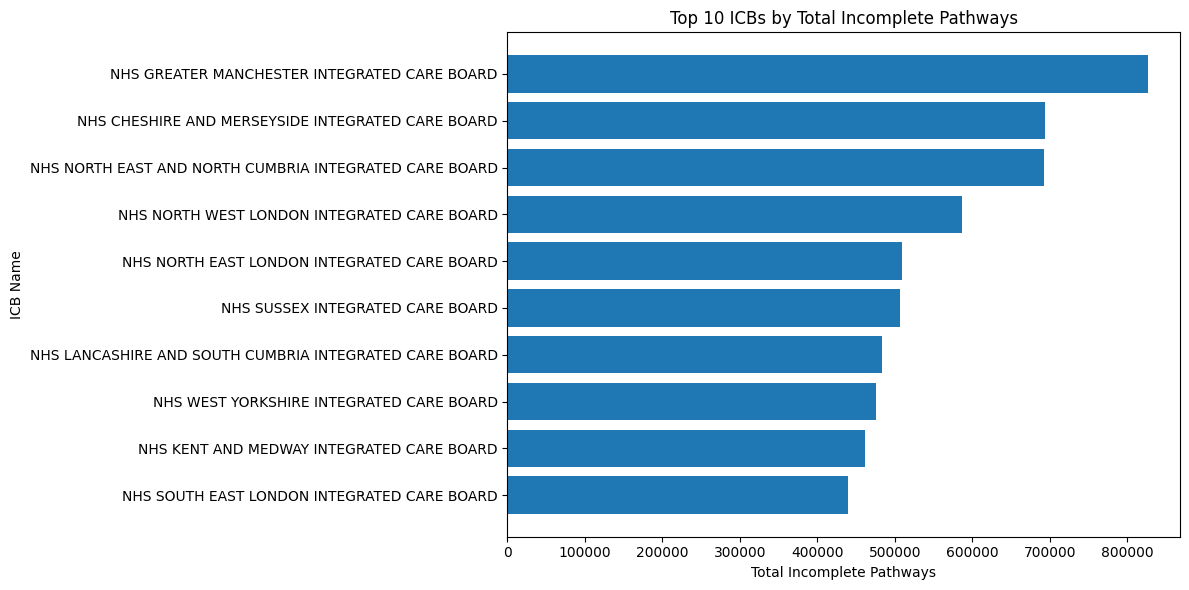

In [153]:
plot_backlog = top_icb_backlog.head(10).sort_values("Total number of incomplete pathways", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(plot_backlog["ICB Name"], plot_backlog["Total number of incomplete pathways"])
plt.title("Top 10 ICBs by Total Incomplete Pathways")
plt.xlabel("Total Incomplete Pathways")
plt.ylabel("ICB Name")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "icb_top10_backlog.png", dpi=300, bbox_inches="tight")
plt.show()

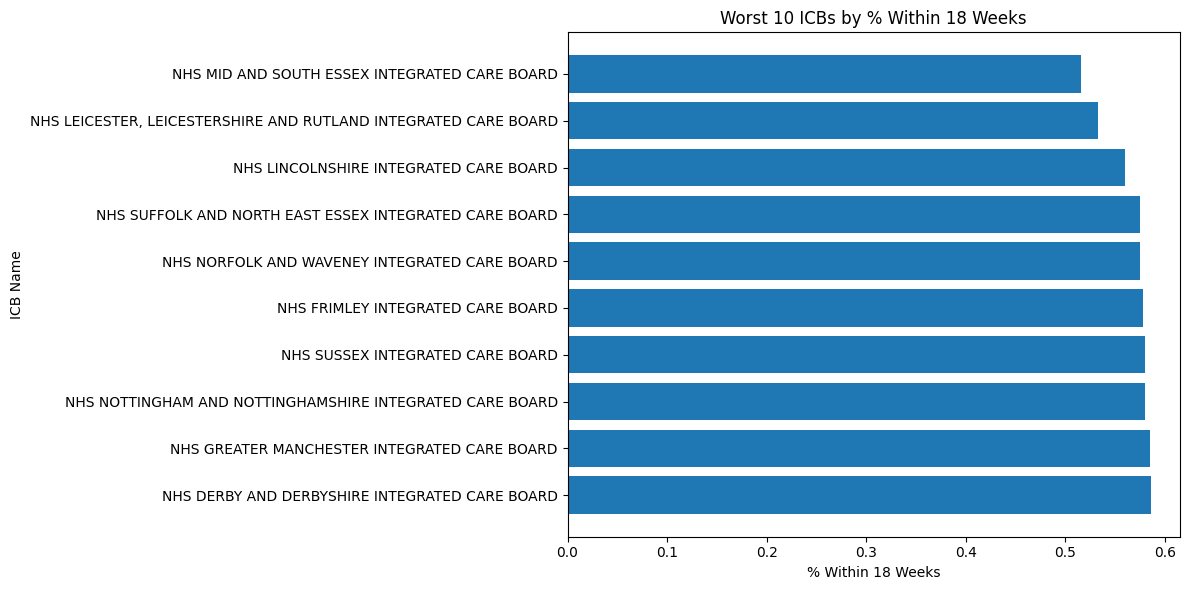

In [155]:
plot_worst18 = worst_icb_18.head(10).sort_values("pct_within_18_weeks", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(plot_worst18["ICB Name"], plot_worst18["pct_within_18_weeks"])
plt.title("Worst 10 ICBs by % Within 18 Weeks")
plt.xlabel("% Within 18 Weeks")
plt.ylabel("ICB Name")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "icb_worst18weeks.png", dpi=300, bbox_inches="tight")
plt.show()

In [157]:
icb_summary.to_csv(BASE_DIR / "outputs" / "tables" / "icb_summary_jan2026.csv", index=False)
icb_summary.head()

,ICB Name,Total number of incomplete pathways,Total within 18 weeks,Total 52 plus weeks,pct_within_18_weeks,pct_52_plus_weeks
0,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...",224902,142128,2488,0.631955,0.011063
1,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...",263738,159906,5020,0.606306,0.019034
2,NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD,312802,192966,2258,0.616895,0.007219
3,NHS BLACK COUNTRY INTEGRATED CARE BOARD,345288,208568,3986,0.604041,0.011544
4,"NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...",175782,122010,758,0.694098,0.004312


In [159]:
icb_metrics = icb_summary[[
    "ICB Name",
    "Total number of incomplete pathways",
    "Total within 18 weeks",
    "Total 52 plus weeks",
    "pct_within_18_weeks",
    "pct_52_plus_weeks"
]].copy()

icb_metrics = icb_metrics.rename(columns={
    "Total number of incomplete pathways": "incomplete_pathways",
    "Total within 18 weeks": "within_18_weeks",
    "Total 52 plus weeks": "plus_52_weeks"
})

icb_metrics.head()

,ICB Name,incomplete_pathways,within_18_weeks,plus_52_weeks,pct_within_18_weeks,pct_52_plus_weeks
0,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...",224902,142128,2488,0.631955,0.011063
1,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...",263738,159906,5020,0.606306,0.019034
2,NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD,312802,192966,2258,0.616895,0.007219
3,NHS BLACK COUNTRY INTEGRATED CARE BOARD,345288,208568,3986,0.604041,0.011544
4,"NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...",175782,122010,758,0.694098,0.004312


In [161]:
icb_metrics["backlog_rank"] = icb_metrics["incomplete_pathways"].rank(ascending=False, method="min")
icb_metrics["worst_18wk_rank"] = icb_metrics["pct_within_18_weeks"].rank(ascending=True, method="min")
icb_metrics["worst_52wk_rank"] = icb_metrics["pct_52_plus_weeks"].rank(ascending=False, method="min")

icb_metrics.sort_values("backlog_rank").head(10)

,ICB Name,incomplete_pathways,within_18_weeks,plus_52_weeks,pct_within_18_weeks,pct_52_plus_weeks,backlog_rank,worst_18wk_rank,worst_52wk_rank
15,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,826752,483718,15844,0.585082,0.019164,1.0,9.0,17.0
7,NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD,693724,408060,15416,0.588217,0.022222,2.0,11.0,9.0
27,NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...,692706,482738,7624,0.696887,0.011006,3.0,41.0,35.0
29,NHS NORTH WEST LONDON INTEGRATED CARE BOARD,586776,367360,6766,0.626065,0.011531,4.0,25.0,33.0
28,NHS NORTH EAST LONDON INTEGRATED CARE BOARD,509642,318136,8092,0.624234,0.015878,5.0,24.0,24.0
40,NHS SUSSEX INTEGRATED CARE BOARD,506204,293396,13550,0.579600,0.026768,6.0,7.0,3.0
21,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,483720,298434,8564,0.616956,0.017704,7.0,23.0,20.0
41,NHS WEST YORKSHIRE INTEGRATED CARE BOARD,475482,323200,3704,0.679731,0.007790,8.0,38.0,38.0
20,NHS KENT AND MEDWAY INTEGRATED CARE BOARD,461150,279398,7526,0.605872,0.016320,9.0,17.0,22.0
34,NHS SOUTH EAST LONDON INTEGRATED CARE BOARD,440038,279494,8522,0.635159,0.019367,10.0,32.0,15.0


In [163]:
icb_metrics.to_csv(BASE_DIR / "outputs" / "tables" / "icb_waiting_metrics_jan2026.csv", index=False)

In [165]:
ons_icb_pop_url = "https://www.ons.gov.uk/file?uri=%2Fpeoplepopulationandcommunity%2Fpopulationandmigration%2Fpopulationestimates%2Fdatasets%2Fclinicalcommissioninggroupmidyearpopulationestimates%2Fmid2022revisednov2025tomid2024integratedcareboards2024geography%2Fsapeicb20222024.xlsx"

ons_pop_book = pd.ExcelFile(ons_icb_pop_url)

print(ons_pop_book.sheet_names)

HTTPError: HTTP Error 403: Forbidden

In [167]:
BASE_DIR / "data" / "raw" / "sapeicb20222024.xlsx"

WindowsPath('C:/Users/swapn/nhs_waiting_list_forecasting/data/raw/sapeicb20222024.xlsx')

In [172]:
C:\Users\swapn\nhs_waiting_list_forecasting\data\raw\

SyntaxError: unexpected character after line continuation character (1143236308.py, line 1)

In [174]:
from urllib.request import Request, urlopen

dataset_page = "https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/clinicalcommissioninggroupmidyearpopulationestimates"
file_url = "https://www.ons.gov.uk/file?uri=%2Fpeoplepopulationandcommunity%2Fpopulationandmigration%2Fpopulationestimates%2Fdatasets%2Fclinicalcommissioninggroupmidyearpopulationestimates%2Fmid2022revisednov2025tomid2024integratedcareboards2024geography%2Fsapeicb20222024.xlsx"

ons_icb_pop_path = BASE_DIR / "data" / "raw" / "sapeicb20222024.xlsx"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": dataset_page,
    "Accept": "application/vnd.openxmlformats-officedocument.spreadsheetml.sheet,application/octet-stream,*/*"
}

req = Request(file_url, headers=headers)

with urlopen(req, timeout=60) as response:
    data = response.read()

with open(ons_icb_pop_path, "wb") as f:
    f.write(data)

print("Saved to:", ons_icb_pop_path)
print("Exists:", ons_icb_pop_path.exists())
print("Size (bytes):", ons_icb_pop_path.stat().st_size)
print("First 2 bytes:", data[:2])

Saved to: C:\Users\swapn\nhs_waiting_list_forecasting\data\raw\sapeicb20222024.xlsx
Exists: True
Size (bytes): 402295
First 2 bytes: b'PK'


In [176]:
ons_pop_book = pd.ExcelFile(ons_icb_pop_path)
print(ons_pop_book.sheet_names)

['Cover sheet', 'Contents', 'Notes', 'Related publications', 'Mid-2022 ICB 2024', 'Mid-2023 ICB 2024', 'Mid-2024 ICB 2024']


In [178]:
ons_pop_raw = pd.read_excel(ons_icb_pop_path, sheet_name="Mid-2024 ICB 2024", header=None)

print(ons_pop_raw.shape)
ons_pop_raw.iloc[:15, :12]

(110, 189)


,0,1,2,3,4,5,6,7,8,9,10,11
0,Estimates by single year of age and sex for 20...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,This worksheet contains one table.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,To turn off freeze panes select the 'View' rib...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SICBL 2024 Code,SICBL 2024 Name,ICB 2024 Code,ICB 2024 Name,NHSER 2024 Code,NHSER 2024 Name,Total,F0,F1,F2,F3,F4
4,E38000006,NHS South Yorkshire ICB - 02P,E54000061,NHS South Yorkshire Integrated Care Board,E40000012,North East and Yorkshire,251770,1246,1244,1313,1373,1353
5,E38000007,NHS Mid and South Essex ICB - 99E,E54000026,NHS Mid and South Essex Integrated Care Board,E40000013,East of England,272958,1521,1564,1680,1651,1770
6,E38000008,NHS Nottingham and Nottinghamshire ICB - 02Q,E54000060,NHS Nottingham and Nottinghamshire Integrated ...,E40000011,Midlands,124937,582,634,585,653,625
7,E38000014,NHS Lancashire and South Cumbria ICB - 00Q,E54000048,NHS Lancashire and South Cumbria Integrated Ca...,E40000014,North West,162540,951,970,1012,1055,1117
8,E38000015,NHS Lancashire and South Cumbria ICB - 00R,E54000048,NHS Lancashire and South Cumbria Integrated Ca...,E40000014,North West,144191,647,708,711,677,805
9,E38000016,NHS Greater Manchester ICB - 00T,E54000057,NHS Greater Manchester Integrated Care Board,E40000014,North West,310085,1750,1756,1939,1920,2110


In [180]:
ons_pop_raw.iloc[:25, :8]

,0,1,2,3,4,5,6,7
0,Estimates by single year of age and sex for 20...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,This worksheet contains one table.,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,To turn off freeze panes select the 'View' rib...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SICBL 2024 Code,SICBL 2024 Name,ICB 2024 Code,ICB 2024 Name,NHSER 2024 Code,NHSER 2024 Name,Total,F0
4,E38000006,NHS South Yorkshire ICB - 02P,E54000061,NHS South Yorkshire Integrated Care Board,E40000012,North East and Yorkshire,251770,1246
5,E38000007,NHS Mid and South Essex ICB - 99E,E54000026,NHS Mid and South Essex Integrated Care Board,E40000013,East of England,272958,1521
6,E38000008,NHS Nottingham and Nottinghamshire ICB - 02Q,E54000060,NHS Nottingham and Nottinghamshire Integrated ...,E40000011,Midlands,124937,582
7,E38000014,NHS Lancashire and South Cumbria ICB - 00Q,E54000048,NHS Lancashire and South Cumbria Integrated Ca...,E40000014,North West,162540,951
8,E38000015,NHS Lancashire and South Cumbria ICB - 00R,E54000048,NHS Lancashire and South Cumbria Integrated Ca...,E40000014,North West,144191,647
9,E38000016,NHS Greater Manchester ICB - 00T,E54000057,NHS Greater Manchester Integrated Care Board,E40000014,North West,310085,1750


In [182]:
ons_pop = pd.read_excel(ons_icb_pop_path, sheet_name="Mid-2024 ICB 2024", header=3)

ons_pop = ons_pop.dropna(axis=1, how="all")
ons_pop = ons_pop.loc[:, ~ons_pop.columns.astype(str).str.contains("^Unnamed")]

print(ons_pop.shape)
print(ons_pop.columns.tolist())
ons_pop.head()

(106, 189)
['SICBL 2024 Code', 'SICBL 2024 Name', 'ICB 2024 Code', 'ICB 2024 Name', 'NHSER 2024 Code', 'NHSER 2024 Name', 'Total', 'F0', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29', 'F30', 'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40', 'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47', 'F48', 'F49', 'F50', 'F51', 'F52', 'F53', 'F54', 'F55', 'F56', 'F57', 'F58', 'F59', 'F60', 'F61', 'F62', 'F63', 'F64', 'F65', 'F66', 'F67', 'F68', 'F69', 'F70', 'F71', 'F72', 'F73', 'F74', 'F75', 'F76', 'F77', 'F78', 'F79', 'F80', 'F81', 'F82', 'F83', 'F84', 'F85', 'F86', 'F87', 'F88', 'F89', 'F90', 'M0', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12', 'M13', 'M14', 'M15', 'M16', 'M17', 'M18', 'M19', 'M20', 'M21', 'M22', 'M23', 'M24', 'M25', 'M26', 'M27', 'M28', 'M29', 'M30', 'M31', 'M32', 'M33', 'M34', 'M35', 

,SICBL 2024 Code,SICBL 2024 Name,ICB 2024 Code,ICB 2024 Name,NHSER 2024 Code,NHSER 2024 Name,Total,F0,F1,F2,...,M81,M82,M83,M84,M85,M86,M87,M88,M89,M90
0,E38000006,NHS South Yorkshire ICB - 02P,E54000061,NHS South Yorkshire Integrated Care Board,E40000012,North East and Yorkshire,251770,1246,1244,1313,...,761,592,511,459,396,394,304,250,231,594
1,E38000007,NHS Mid and South Essex ICB - 99E,E54000026,NHS Mid and South Essex Integrated Care Board,E40000013,East of England,272958,1521,1564,1680,...,689,562,450,434,420,430,344,305,274,845
2,E38000008,NHS Nottingham and Nottinghamshire ICB - 02Q,E54000060,NHS Nottingham and Nottinghamshire Integrated ...,E40000011,Midlands,124937,582,634,585,...,418,324,296,288,254,230,185,150,140,424
3,E38000014,NHS Lancashire and South Cumbria ICB - 00Q,E54000048,NHS Lancashire and South Cumbria Integrated Ca...,E40000014,North West,162540,951,970,1012,...,281,257,225,201,193,185,135,116,102,291
4,E38000015,NHS Lancashire and South Cumbria ICB - 00R,E54000048,NHS Lancashire and South Cumbria Integrated Ca...,E40000014,North West,144191,647,708,711,...,443,338,308,271,286,243,187,185,129,449


In [184]:
ons_icb_pop = ons_pop[[
    "ICB 2024 Code",
    "ICB 2024 Name",
    "Total"
]].copy()

ons_icb_pop["Total"] = pd.to_numeric(ons_icb_pop["Total"], errors="coerce")

print(ons_icb_pop.shape)
ons_icb_pop.head()

(106, 3)


,ICB 2024 Code,ICB 2024 Name,Total
0,E54000061,NHS South Yorkshire Integrated Care Board,251770
1,E54000026,NHS Mid and South Essex Integrated Care Board,272958
2,E54000060,NHS Nottingham and Nottinghamshire Integrated ...,124937
3,E54000048,NHS Lancashire and South Cumbria Integrated Ca...,162540
4,E54000048,NHS Lancashire and South Cumbria Integrated Ca...,144191


In [186]:
ons_icb_pop_agg = (
    ons_icb_pop.groupby(["ICB 2024 Code", "ICB 2024 Name"], as_index=False)["Total"]
    .sum()
    .rename(columns={
        "ICB 2024 Code": "ICB Code",
        "ICB 2024 Name": "ICB Name",
        "Total": "population_2024"
    })
)

print(ons_icb_pop_agg.shape)
ons_icb_pop_agg.head()

(42, 3)


,ICB Code,ICB Name,population_2024
0,E54000008,NHS Cheshire and Merseyside Integrated Care Board,2615425
1,E54000010,NHS Staffordshire and Stoke-on-Trent Integrate...,1177578
2,E54000011,"NHS Shropshire, Telford and Wrekin Integrated ...",528407
3,E54000013,NHS Lincolnshire Integrated Care Board,789502
4,E54000015,"NHS Leicester, Leicestershire and Rutland Inte...",1175364


In [188]:
icb_summary_code = (
    icb_working.groupby(["ICB Code", "ICB Name"], as_index=False)
    .agg({
        "Total number of incomplete pathways": "sum",
        "Total within 18 weeks": "sum",
        "Total 52 plus weeks": "sum"
    })
)

icb_summary_code["pct_within_18_weeks"] = (
    icb_summary_code["Total within 18 weeks"] / icb_summary_code["Total number of incomplete pathways"]
)

icb_summary_code["pct_52_plus_weeks"] = (
    icb_summary_code["Total 52 plus weeks"] / icb_summary_code["Total number of incomplete pathways"]
)

print(icb_summary_code.shape)
icb_summary_code.head()

(42, 7)


,ICB Code,ICB Name,Total number of incomplete pathways,Total within 18 weeks,Total 52 plus weeks,pct_within_18_weeks,pct_52_plus_weeks
0,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,483720,298434,8564,0.616956,0.017704
1,QF7,NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD,212368,139464,2950,0.656709,0.013891
2,QGH,NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...,185508,112732,2532,0.607693,0.013649
3,QH8,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,397540,205074,27160,0.515858,0.068320
4,QHG,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...",263738,159906,5020,0.606306,0.019034


In [190]:
icb_pop_merged = icb_summary_code.merge(
    ons_icb_pop_agg,
    on=["ICB Code", "ICB Name"],
    how="left"
)

print(icb_pop_merged.shape)
print("Missing population rows:", icb_pop_merged["population_2024"].isna().sum())
icb_pop_merged.head()

(42, 8)
Missing population rows: 42


,ICB Code,ICB Name,Total number of incomplete pathways,Total within 18 weeks,Total 52 plus weeks,pct_within_18_weeks,pct_52_plus_weeks,population_2024
0,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,483720,298434,8564,0.616956,0.017704,NaN
1,QF7,NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD,212368,139464,2950,0.656709,0.013891,NaN
2,QGH,NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...,185508,112732,2532,0.607693,0.013649,NaN
3,QH8,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,397540,205074,27160,0.515858,0.068320,NaN
4,QHG,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...",263738,159906,5020,0.606306,0.019034,NaN


In [192]:
icb_pop_merged["backlog_per_100k"] = (
    icb_pop_merged["Total number of incomplete pathways"] / icb_pop_merged["population_2024"]
) * 100000

icb_pop_merged["plus_52_per_100k"] = (
    icb_pop_merged["Total 52 plus weeks"] / icb_pop_merged["population_2024"]
) * 100000

icb_pop_merged[[
    "ICB Name",
    "population_2024",
    "Total number of incomplete pathways",
    "backlog_per_100k",
    "Total 52 plus weeks",
    "plus_52_per_100k",
    "pct_within_18_weeks"
]].sort_values("backlog_per_100k", ascending=False).head(10)

,ICB Name,population_2024,Total number of incomplete pathways,backlog_per_100k,Total 52 plus weeks,plus_52_per_100k,pct_within_18_weeks
0,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,NaN,483720,NaN,8564,NaN,0.616956
1,NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD,NaN,212368,NaN,2950,NaN,0.656709
2,NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...,NaN,185508,NaN,2532,NaN,0.607693
3,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,NaN,397540,NaN,27160,NaN,0.515858
4,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...",NaN,263738,NaN,5020,NaN,0.606306
5,NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD,NaN,312802,NaN,2258,NaN,0.616895
6,NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...,NaN,692706,NaN,7624,NaN,0.696887
7,NHS DERBY AND DERBYSHIRE INTEGRATED CARE BOARD,NaN,232680,NaN,5508,NaN,0.585706
8,NHS SUFFOLK AND NORTH EAST ESSEX INTEGRATED CA...,NaN,258852,NaN,5644,NaN,0.574405
9,NHS DEVON INTEGRATED CARE BOARD,NaN,310660,NaN,6678,NaN,0.632222


In [194]:
icb_waiting_for_merge = icb_summary_code.copy()
ons_pop_for_merge = ons_icb_pop_agg.copy()

icb_waiting_for_merge["name_key"] = (
    icb_waiting_for_merge["ICB Name"]
    .astype(str)
    .str.lower()
    .str.replace("&", "and", regex=False)
    .str.replace("-", " ", regex=False)
    .str.replace(",", " ", regex=False)
    .str.replace(r"\bnhs\b", "", regex=True)
    .str.replace(r"\bintegrated care board\b", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

ons_pop_for_merge["name_key"] = (
    ons_pop_for_merge["ICB Name"]
    .astype(str)
    .str.lower()
    .str.replace("&", "and", regex=False)
    .str.replace("-", " ", regex=False)
    .str.replace(",", " ", regex=False)
    .str.replace(r"\bnhs\b", "", regex=True)
    .str.replace(r"\bintegrated care board\b", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

icb_pop_merged = icb_waiting_for_merge.merge(
    ons_pop_for_merge[["ICB Name", "population_2024", "name_key"]],
    on="name_key",
    how="left",
    suffixes=("_waiting", "_ons")
)

print(icb_pop_merged.shape)
print("Missing population rows:", icb_pop_merged["population_2024"].isna().sum())

icb_pop_merged[[
    "ICB Code",
    "ICB Name_waiting",
    "ICB Name_ons",
    "population_2024"
]].head()

(42, 10)
Missing population rows: 0


,ICB Code,ICB Name_waiting,ICB Name_ons,population_2024
0,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,NHS Lancashire and South Cumbria Integrated Ca...,1790318
1,QF7,NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD,NHS South Yorkshire Integrated Care Board,1430623
2,QGH,NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...,NHS Herefordshire and Worcestershire Integrate...,812407
3,QH8,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,NHS Mid and South Essex Integrated Care Board,1241837
4,QHG,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...","NHS Bedfordshire, Luton and Milton Keynes Inte...",1063247


In [196]:
icb_pop_merged.loc[
    icb_pop_merged["population_2024"].isna(),
    ["ICB Code", "ICB Name_waiting", "name_key"]
].sort_values("ICB Name_waiting")

,ICB Code,ICB Name_waiting,name_key


In [198]:
icb_pop_merged["backlog_per_100k"] = (
    icb_pop_merged["Total number of incomplete pathways"] / icb_pop_merged["population_2024"]
) * 100000

icb_pop_merged["plus_52_per_100k"] = (
    icb_pop_merged["Total 52 plus weeks"] / icb_pop_merged["population_2024"]
) * 100000

icb_pop_merged[[
    "ICB Name_waiting",
    "population_2024",
    "Total number of incomplete pathways",
    "backlog_per_100k",
    "Total 52 plus weeks",
    "plus_52_per_100k",
    "pct_within_18_weeks"
]].sort_values("backlog_per_100k", ascending=False).head(10)

,ICB Name_waiting,population_2024,Total number of incomplete pathways,backlog_per_100k,Total 52 plus weeks,plus_52_per_100k,pct_within_18_weeks
3,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,1241837,397540,32012.252816,27160,2187.082524,0.515858
20,NHS SUSSEX INTEGRATED CARE BOARD,1759789,506204,28765.039445,13550,769.978674,0.579600
16,NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD,1436301,407102,28343.780308,6174,429.854188,0.612991
22,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,3009664,826752,27469.910262,15844,526.437503,0.585082
33,NHS BLACK COUNTRY INTEGRATED CARE BOARD,1262719,345288,27344.801179,3986,315.668015,0.604041
10,NHS LINCOLNSHIRE INTEGRATED CARE BOARD,789502,214790,27205.757553,2288,289.802939,0.560175
0,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,1790318,483720,27018.663723,8564,478.350773,0.616956
28,NHS NORTH WEST LONDON INTEGRATED CARE BOARD,2181495,586776,26897.884249,6766,310.154275,0.626065
40,NHS SURREY HEARTLANDS INTEGRATED CARE BOARD,1085554,288018,26531.890629,4034,371.607493,0.637870
41,NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD,2615425,693724,26524.331610,15416,589.426193,0.588217


In [200]:
icb_pop_merged["backlog_per_100k"] = (
    icb_pop_merged["Total number of incomplete pathways"] / icb_pop_merged["population_2024"]
) * 100000

icb_pop_merged["plus_52_per_100k"] = (
    icb_pop_merged["Total 52 plus weeks"] / icb_pop_merged["population_2024"]
) * 100000

icb_pop_merged["within_18_per_100k"] = (
    icb_pop_merged["Total within 18 weeks"] / icb_pop_merged["population_2024"]
) * 100000

icb_pop_merged[[
    "ICB Code",
    "ICB Name_waiting",
    "population_2024",
    "Total number of incomplete pathways",
    "backlog_per_100k",
    "Total 52 plus weeks",
    "plus_52_per_100k",
    "pct_within_18_weeks"
]].sort_values("backlog_per_100k", ascending=False).head(10)

,ICB Code,ICB Name_waiting,population_2024,Total number of incomplete pathways,backlog_per_100k,Total 52 plus weeks,plus_52_per_100k,pct_within_18_weeks
3,QH8,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,1241837,397540,32012.252816,27160,2187.082524,0.515858
20,QNX,NHS SUSSEX INTEGRATED CARE BOARD,1759789,506204,28765.039445,13550,769.978674,0.579600
16,QMJ,NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD,1436301,407102,28343.780308,6174,429.854188,0.612991
22,QOP,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,3009664,826752,27469.910262,15844,526.437503,0.585082
33,QUA,NHS BLACK COUNTRY INTEGRATED CARE BOARD,1262719,345288,27344.801179,3986,315.668015,0.604041
10,QJM,NHS LINCOLNSHIRE INTEGRATED CARE BOARD,789502,214790,27205.757553,2288,289.802939,0.560175
0,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,1790318,483720,27018.663723,8564,478.350773,0.616956
28,QRV,NHS NORTH WEST LONDON INTEGRATED CARE BOARD,2181495,586776,26897.884249,6766,310.154275,0.626065
40,QXU,NHS SURREY HEARTLANDS INTEGRATED CARE BOARD,1085554,288018,26531.890629,4034,371.607493,0.637870
41,QYG,NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD,2615425,693724,26524.331610,15416,589.426193,0.588217


In [202]:
icb_final = icb_pop_merged[[
    "ICB Code",
    "ICB Name_waiting",
    "population_2024",
    "Total number of incomplete pathways",
    "Total within 18 weeks",
    "Total 52 plus weeks",
    "pct_within_18_weeks",
    "pct_52_plus_weeks",
    "backlog_per_100k",
    "plus_52_per_100k",
    "within_18_per_100k"
]].copy()

icb_final = icb_final.rename(columns={
    "ICB Name_waiting": "ICB Name",
    "Total number of incomplete pathways": "incomplete_pathways",
    "Total within 18 weeks": "within_18_weeks",
    "Total 52 plus weeks": "plus_52_plus_weeks"
})

icb_final.to_csv(BASE_DIR / "outputs" / "tables" / "icb_final_waiting_population_metrics.csv", index=False)

print(icb_final.shape)
icb_final.head()

(42, 11)


,ICB Code,ICB Name,population_2024,incomplete_pathways,within_18_weeks,plus_52_plus_weeks,pct_within_18_weeks,pct_52_plus_weeks,backlog_per_100k,plus_52_per_100k,within_18_per_100k
0,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,1790318,483720,298434,8564,0.616956,0.017704,27018.663723,478.350773,16669.329136
1,QF7,NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD,1430623,212368,139464,2950,0.656709,0.013891,14844.441897,206.203871,9748.480208
2,QGH,NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...,812407,185508,112732,2532,0.607693,0.013649,22834.367503,311.666443,13876.295994
3,QH8,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,1241837,397540,205074,27160,0.515858,0.068320,32012.252816,2187.082524,16513.761468
4,QHG,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...",1063247,263738,159906,5020,0.606306,0.019034,24804.960654,472.138647,15039.402886


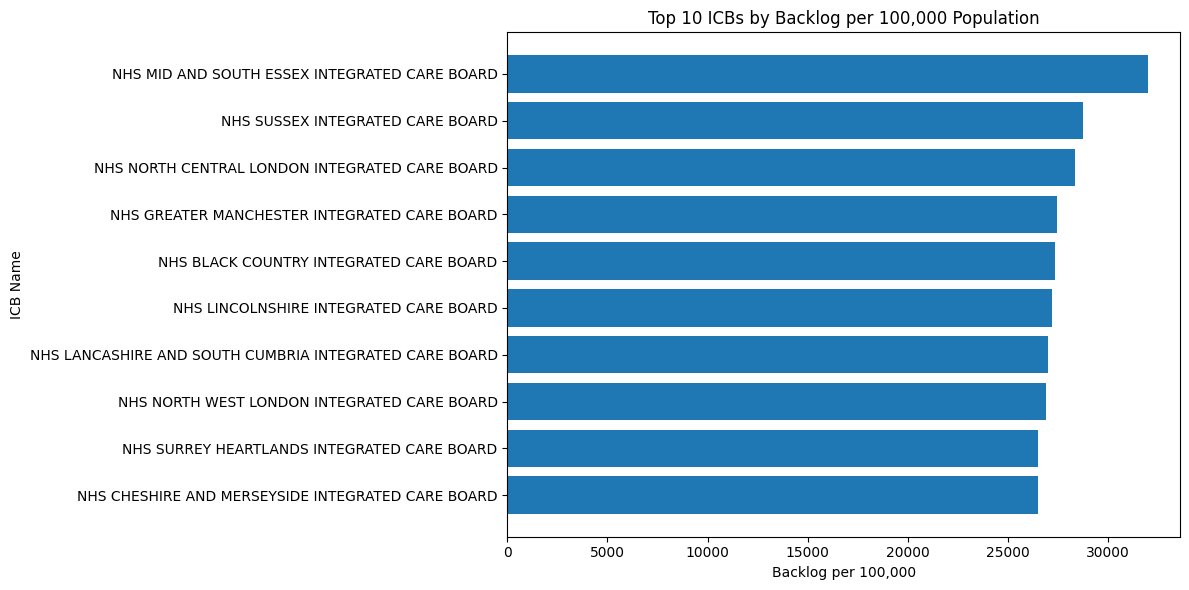

In [204]:
plot_backlog_per100k = icb_final.sort_values("backlog_per_100k", ascending=False).head(10)
plot_backlog_per100k = plot_backlog_per100k.sort_values("backlog_per_100k", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(plot_backlog_per100k["ICB Name"], plot_backlog_per100k["backlog_per_100k"])
plt.title("Top 10 ICBs by Backlog per 100,000 Population")
plt.xlabel("Backlog per 100,000")
plt.ylabel("ICB Name")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "icb_top10_backlog_per100k.png", dpi=300, bbox_inches="tight")
plt.show()

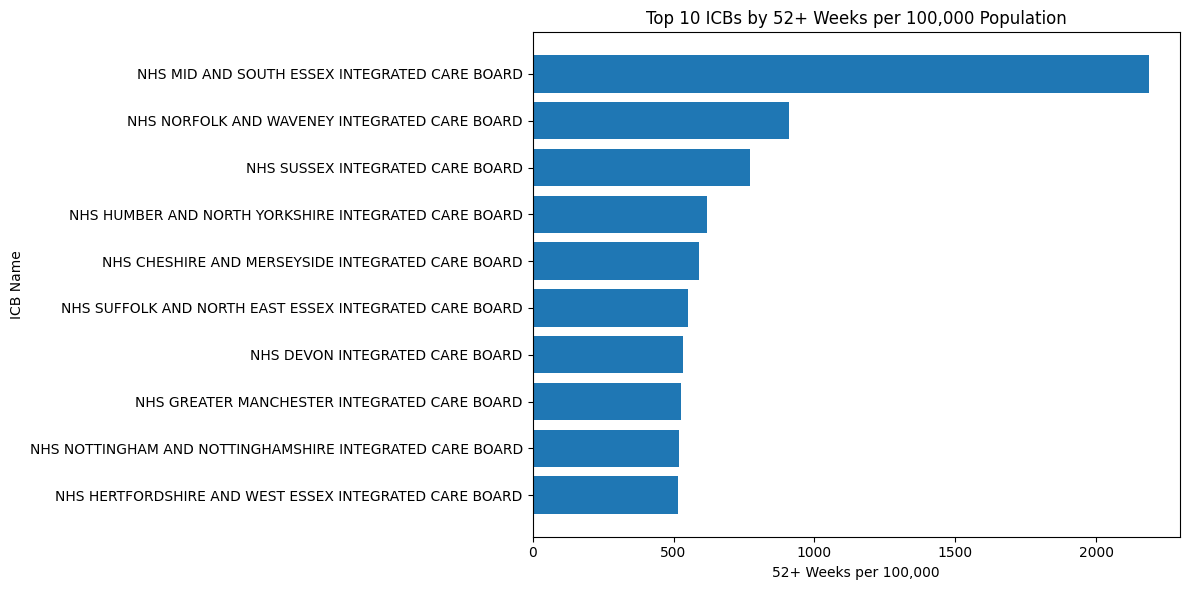

In [206]:
plot_52_per100k = icb_final.sort_values("plus_52_per_100k", ascending=False).head(10)
plot_52_per100k = plot_52_per100k.sort_values("plus_52_per_100k", ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(plot_52_per100k["ICB Name"], plot_52_per100k["plus_52_per_100k"])
plt.title("Top 10 ICBs by 52+ Weeks per 100,000 Population")
plt.xlabel("52+ Weeks per 100,000")
plt.ylabel("ICB Name")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "icb_top10_52plus_per100k.png", dpi=300, bbox_inches="tight")
plt.show()

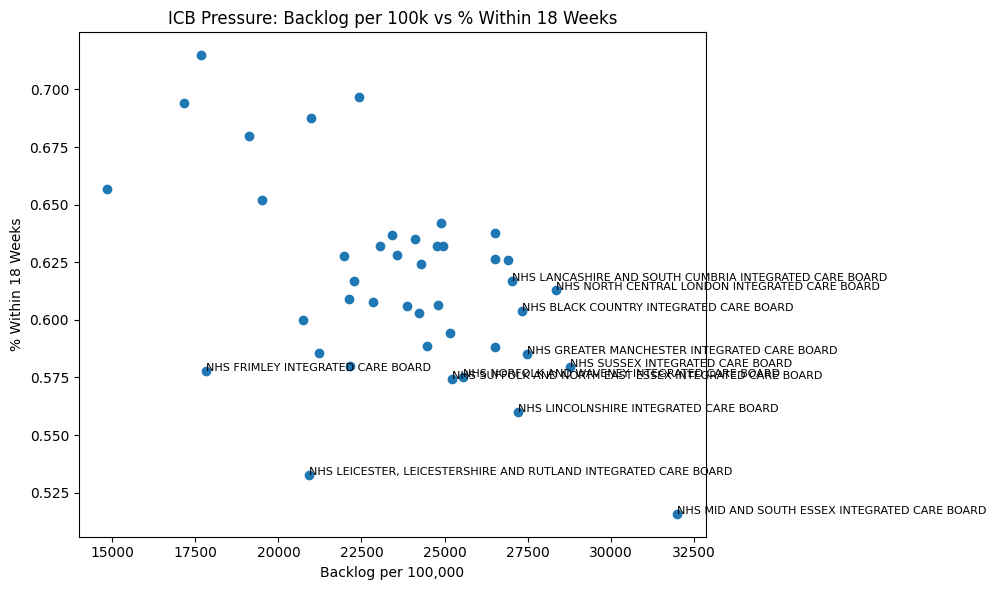

In [208]:
plt.figure(figsize=(10, 6))
plt.scatter(icb_final["backlog_per_100k"], icb_final["pct_within_18_weeks"])

for _, row in icb_final.iterrows():
    if row["backlog_per_100k"] >= icb_final["backlog_per_100k"].quantile(0.85) or row["pct_within_18_weeks"] <= icb_final["pct_within_18_weeks"].quantile(0.15):
        plt.annotate(
            row["ICB Name"],
            (row["backlog_per_100k"], row["pct_within_18_weeks"]),
            fontsize=8
        )

plt.title("ICB Pressure: Backlog per 100k vs % Within 18 Weeks")
plt.xlabel("Backlog per 100,000")
plt.ylabel("% Within 18 Weeks")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "icb_backlog_per100k_vs_18weeks.png", dpi=300, bbox_inches="tight")
plt.show()

In [210]:
icb_final.sort_values(["backlog_per_100k", "plus_52_per_100k"], ascending=[False, False]).head(15)

,ICB Code,ICB Name,population_2024,incomplete_pathways,within_18_weeks,plus_52_plus_weeks,pct_within_18_weeks,pct_52_plus_weeks,backlog_per_100k,plus_52_per_100k,within_18_per_100k
3,QH8,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,1241837,397540,205074,27160,0.515858,0.068320,32012.252816,2187.082524,16513.761468
20,QNX,NHS SUSSEX INTEGRATED CARE BOARD,1759789,506204,293396,13550,0.579600,0.026768,28765.039445,769.978674,16672.226045
16,QMJ,NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD,1436301,407102,249550,6174,0.612991,0.015166,28343.780308,429.854188,17374.491837
22,QOP,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,3009664,826752,483718,15844,0.585082,0.019164,27469.910262,526.437503,16072.159550
33,QUA,NHS BLACK COUNTRY INTEGRATED CARE BOARD,1262719,345288,208568,3986,0.604041,0.011544,27344.801179,315.668015,16517.372432
10,QJM,NHS LINCOLNSHIRE INTEGRATED CARE BOARD,789502,214790,120320,2288,0.560175,0.010652,27205.757553,289.802939,15239.986726
0,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,1790318,483720,298434,8564,0.616956,0.017704,27018.663723,478.350773,16669.329136
28,QRV,NHS NORTH WEST LONDON INTEGRATED CARE BOARD,2181495,586776,367360,6766,0.626065,0.011531,26897.884249,310.154275,16839.827733
40,QXU,NHS SURREY HEARTLANDS INTEGRATED CARE BOARD,1085554,288018,183718,4034,0.637870,0.014006,26531.890629,371.607493,16923.893238
41,QYG,NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD,2615425,693724,408060,15416,0.588217,0.022222,26524.331610,589.426193,15602.053204


In [212]:
project_summary = pd.DataFrame({
    "section": [
        "National forecast accuracy",
        "Top specialty backlog",
        "Weakest specialty by 18-week performance",
        "Top ICB by raw backlog",
        "Top ICB by backlog per 100k",
        "Top ICB by 52+ weeks per 100k"
    ],
    "result": [
        f"MAPE = {mape:.2f}%, MAE = {mae:,.0f}, RMSE = {rmse:,.0f}",
        "Trauma and Orthopaedic Service",
        "Oral Surgery Service",
        top_icb_backlog.iloc[0]['ICB Name'],
        icb_final.sort_values('backlog_per_100k', ascending=False).iloc[0]['ICB Name'],
        icb_final.sort_values('plus_52_per_100k', ascending=False).iloc[0]['ICB Name']
    ],
    "value": [
        "",
        int(top_backlog.iloc[0]["incomplete_pathways"]),
        float(worst_18_week.iloc[0]["pct_within_18_weeks"]),
        int(top_icb_backlog.iloc[0]["Total number of incomplete pathways"]),
        float(icb_final.sort_values("backlog_per_100k", ascending=False).iloc[0]["backlog_per_100k"]),
        float(icb_final.sort_values("plus_52_per_100k", ascending=False).iloc[0]["plus_52_per_100k"])
    ]
})

project_summary

,section,result,value
0,National forecast accuracy,"MAPE = 1.23%, MAE = 89,075, RMSE = 113,131",
1,Top specialty backlog,Trauma and Orthopaedic Service,836764
2,Weakest specialty by 18-week performance,Oral Surgery Service,52.4
3,Top ICB by raw backlog,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,826752
4,Top ICB by backlog per 100k,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,32012.252816
5,Top ICB by 52+ weeks per 100k,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,2187.082524


In [214]:
project_summary.to_csv(BASE_DIR / "outputs" / "tables" / "project_summary_table.csv", index=False)

In [216]:
final_ranked_icbs = icb_final[[
    "ICB Code",
    "ICB Name",
    "population_2024",
    "incomplete_pathways",
    "backlog_per_100k",
    "plus_52_plus_weeks",
    "plus_52_per_100k",
    "pct_within_18_weeks",
    "pct_52_plus_weeks"
]].sort_values(
    ["backlog_per_100k", "plus_52_per_100k"],
    ascending=[False, False]
).reset_index(drop=True)

final_ranked_icbs.head(15)

,ICB Code,ICB Name,population_2024,incomplete_pathways,backlog_per_100k,plus_52_plus_weeks,plus_52_per_100k,pct_within_18_weeks,pct_52_plus_weeks
0,QH8,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,1241837,397540,32012.252816,27160,2187.082524,0.515858,0.068320
1,QNX,NHS SUSSEX INTEGRATED CARE BOARD,1759789,506204,28765.039445,13550,769.978674,0.579600,0.026768
2,QMJ,NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD,1436301,407102,28343.780308,6174,429.854188,0.612991,0.015166
3,QOP,NHS GREATER MANCHESTER INTEGRATED CARE BOARD,3009664,826752,27469.910262,15844,526.437503,0.585082,0.019164
4,QUA,NHS BLACK COUNTRY INTEGRATED CARE BOARD,1262719,345288,27344.801179,3986,315.668015,0.604041,0.011544
5,QJM,NHS LINCOLNSHIRE INTEGRATED CARE BOARD,789502,214790,27205.757553,2288,289.802939,0.560175,0.010652
6,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,1790318,483720,27018.663723,8564,478.350773,0.616956,0.017704
7,QRV,NHS NORTH WEST LONDON INTEGRATED CARE BOARD,2181495,586776,26897.884249,6766,310.154275,0.626065,0.011531
8,QXU,NHS SURREY HEARTLANDS INTEGRATED CARE BOARD,1085554,288018,26531.890629,4034,371.607493,0.637870,0.014006
9,QYG,NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD,2615425,693724,26524.331610,15416,589.426193,0.588217,0.022222


In [218]:
final_ranked_icbs.to_csv(BASE_DIR / "outputs" / "tables" / "final_ranked_icbs.csv", index=False)